# Configure SBS Parameters

This notebook should be used as a test for ensuring correct SBS image loading and processing before running the SBS module.
Cells marked with <font color='red'>SET PARAMETERS</font> contain crucial variables that need to be set according to your specific experimental setup and data organization.
Please review and modify these variables as needed before proceeding with the analysis.

## <font color='red'>SET PARAMETERS</font>

### Fixed parameters for SBS processing

- `CONFIG_FILE_PATH`: Path to a Brieflow config file used during processing. Absolute or relative to where workflows are run from.

In [1]:
CONFIG_FILE_PATH = "config/config.yml"

## Imports

In [2]:
from pathlib import Path

import yaml
from tifffile import imread
import pandas as pd
from snakemake.io import expand
from microfilm.microplot import Microimage
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from lib.shared.configuration_utils import (
    CONFIG_FILE_HEADER,
    create_micropanel,
    random_cmap,
    image_segmentation_annotations,
)
from lib.shared.file_utils import get_filename
from lib.sbs.barcode_cycle_utils import compute_barcode_cycle_positions
from lib.sbs.align_cycles import align_cycles
from lib.shared.log_filter import log_filter
from lib.sbs.compute_standard_deviation import compute_standard_deviation
from lib.sbs.max_filter import max_filter
from lib.sbs.find_peaks import find_peaks, find_peaks_spotiflow, plot_channels_with_peaks
from lib.shared.illumination_correction import apply_ic_field, combine_ic_images
from lib.shared.segment_cellpose import prepare_cellpose
from lib.cluster.scrape_benchmarks import get_uniprot_data
from lib.sbs.standardize_barcode_design import standardize_barcode_design, get_barcode_list
from lib.sbs.extract_bases import extract_bases
from lib.sbs.call_reads import call_reads, plot_normalization_comparison
from lib.sbs.call_cells import call_cells
from lib.sbs.call_cells_multi import prep_multi_reads, call_cells_multi
from lib.shared.extract_phenotype_minimal import extract_phenotype_minimal
from lib.sbs.eval_mapping import (
    plot_mapping_vs_threshold,
    plot_cell_mapping_heatmap,
    plot_cell_metric_histogram,
    plot_gene_symbol_histogram,
)
from lib.sbs.automated_parameter_search import (
    automated_parameter_search,
    visualize_parameter_results,
    get_best_parameters
)

/lab/solexa_lourido/USERS/AK/miniforge3/envs/brieflow_nebo/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm




Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.4 
platform:       	linux 
python version: 	3.11.13 
torch version:  	2.7.0+cu126! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




## <font color='red'>SET PARAMETERS</font>

### Parameters for testing SBS processing

- `TEST_PLATE`, `TEST_WELL`, `TEST_TILE`: Plate/well/tile combination used for configuring parameters in this notebook.

### Channels

- `CHANNEL_NAMES`: A list of ordered names for each channel in your SBS image. 
- `CHANNEL_CMAPS`: A list of color maps to use when showing channel microimages. These need to be a Matplotlib or microfilm colormap. We recommend using: `["pure_red", "pure_green", "pure_blue", "pure_cyan", "pure_magenta", "pure_yellow"]`.

In [3]:
# Define test well and tile
TEST_PLATE = 1
TEST_WELL = "A3"
TEST_TILE = 120
# Derive wildcard dictionary for testing
WILDCARDS = dict(well=TEST_WELL, tile=TEST_TILE)

# Define image channels with DAPI as the first channel
CHANNEL_NAMES = ["DAPI", "G", "T", "A", "C"]
CHANNEL_CMAPS = ["pure_cyan", "pure_yellow", "pure_magenta", "pure_green", "pure_red"]


# Remove DAPI channel to get bases
BASES = [channel for channel in CHANNEL_NAMES if channel in ["G", "T", "A", "C"]]
EXTRA_CHANNELS = [channel for channel in CHANNEL_NAMES if channel not in ["G", "T", "A", "C"]]

## <font color='red'>SET PARAMETERS</font>

### Alignment
- `ALIGNMENT_METHOD`: Optional. Method for aligning SBS images between cycles. If not specified, the method will be automatically selected based on available channels, but can be overridden by the user:
    - `DAPI`: the DAPI channel is used for alignment between cycles. Automatically selected if **DAPI is present in each** round of SBS imaging.
    - `sbs_mean`: the mean intensity of base channels is used for alignment between cycles. Automatically selected if **DAPI is not present in each** round of SBS imaging.
- `UPSAMPLE_FACTOR`: Factor used for subpixel alignment. Defaults to `2`
    - Higher values provide more precise alignment but increase processing time.
    - Set to `1` to disable subpixel alignment for faster processing.
- `SKIP_CYCLES`: Optional. List of cycle indices to skip during alignment. Defaults to `None`
    - Use this to exclude problematic cycles that would interfere with alignment
    - Example: `[1]` to skip the first cycle, `[1, 6]` to skip cycles 1 and 6
    - Skipped cycles are completely removed from processing and will not appear in final results
- `MANUAL_BACKGROUND_CYCLE`: Optional. Specific cycle to use as the source for segmentation background channels. Defaults to `None`
    - Use this when you have segmentation channels (e.g., DAPI, GFP) in a specific cycle that you want propagated to all cycles
    - If not specified, automatically selects the cycle with the most extra (non-GTAC) channels
    - Example: `12` to use cycle 12 as the source for background channels
    - Note: This refers to the original cycle index before any cycles are skipped

In [4]:
ALIGNMENT_METHOD = "DAPI"
UPSAMPLE_FACTOR = 2
SKIP_CYCLES = None
SKIP_CYCLES_INDICES = None 
MANUAL_BACKGROUND_CYCLE = None

Loading test images...
Image shapes before alignment:
  Cycle 1: (5, 1200, 1200)
  Cycle 2: (5, 1200, 1200)
  Cycle 3: (5, 1200, 1200)
  Cycle 4: (5, 1200, 1200)
  Cycle 5: (5, 2400, 2400)
  Cycle 6: (5, 1200, 1200)
  Cycle 7: (5, 1200, 1200)
  Cycle 8: (5, 1200, 1200)
  Cycle 9: (5, 1200, 1200)

Aligning test images with resize handling...
Found 2 different spatial shapes: [(1200, 1200), (2400, 2400)]
Shape counts: [((1200, 1200), 8), ((2400, 2400), 1)]
Target spatial shape: (1200, 1200)
Cycle 0: keeping original shape (1200, 1200)
Cycle 1: keeping original shape (1200, 1200)
Cycle 2: keeping original shape (1200, 1200)
Cycle 3: keeping original shape (1200, 1200)
Cycle 4: resizing from (2400, 2400) to (1200, 1200)
Cycle 5: keeping original shape (1200, 1200)
Cycle 6: keeping original shape (1200, 1200)
Cycle 7: keeping original shape (1200, 1200)
Cycle 8: keeping original shape (1200, 1200)
Final stacked shape before alignment: (9, 5, 1200, 1200)

Final aligned shape: (9, 5, 1200, 12

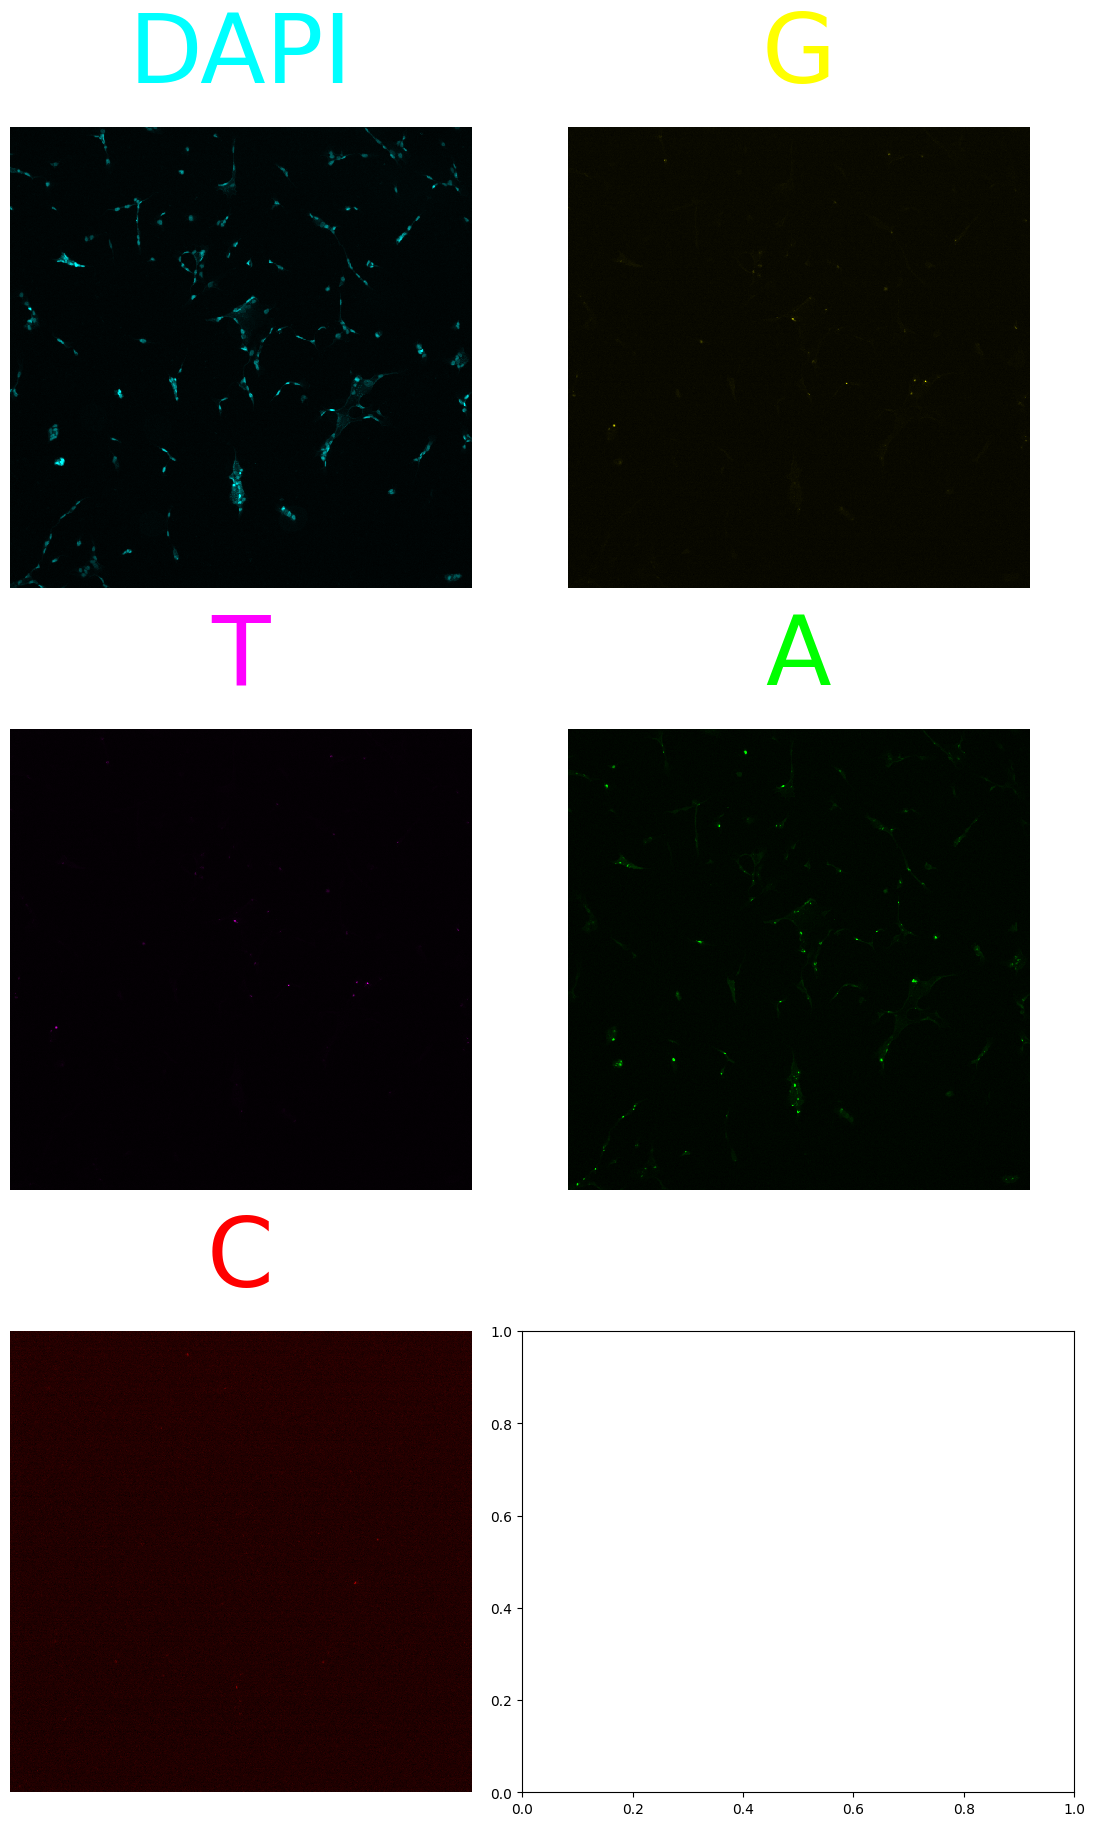


Found cycles with different spatial shapes: [(1200, 1200), (2400, 2400)]
Cycle with shape (2400, 2400) was resized to (1200, 1200)

Showing before/after comparison for resized cycle (aligned index 4):
After resizing and alignment:


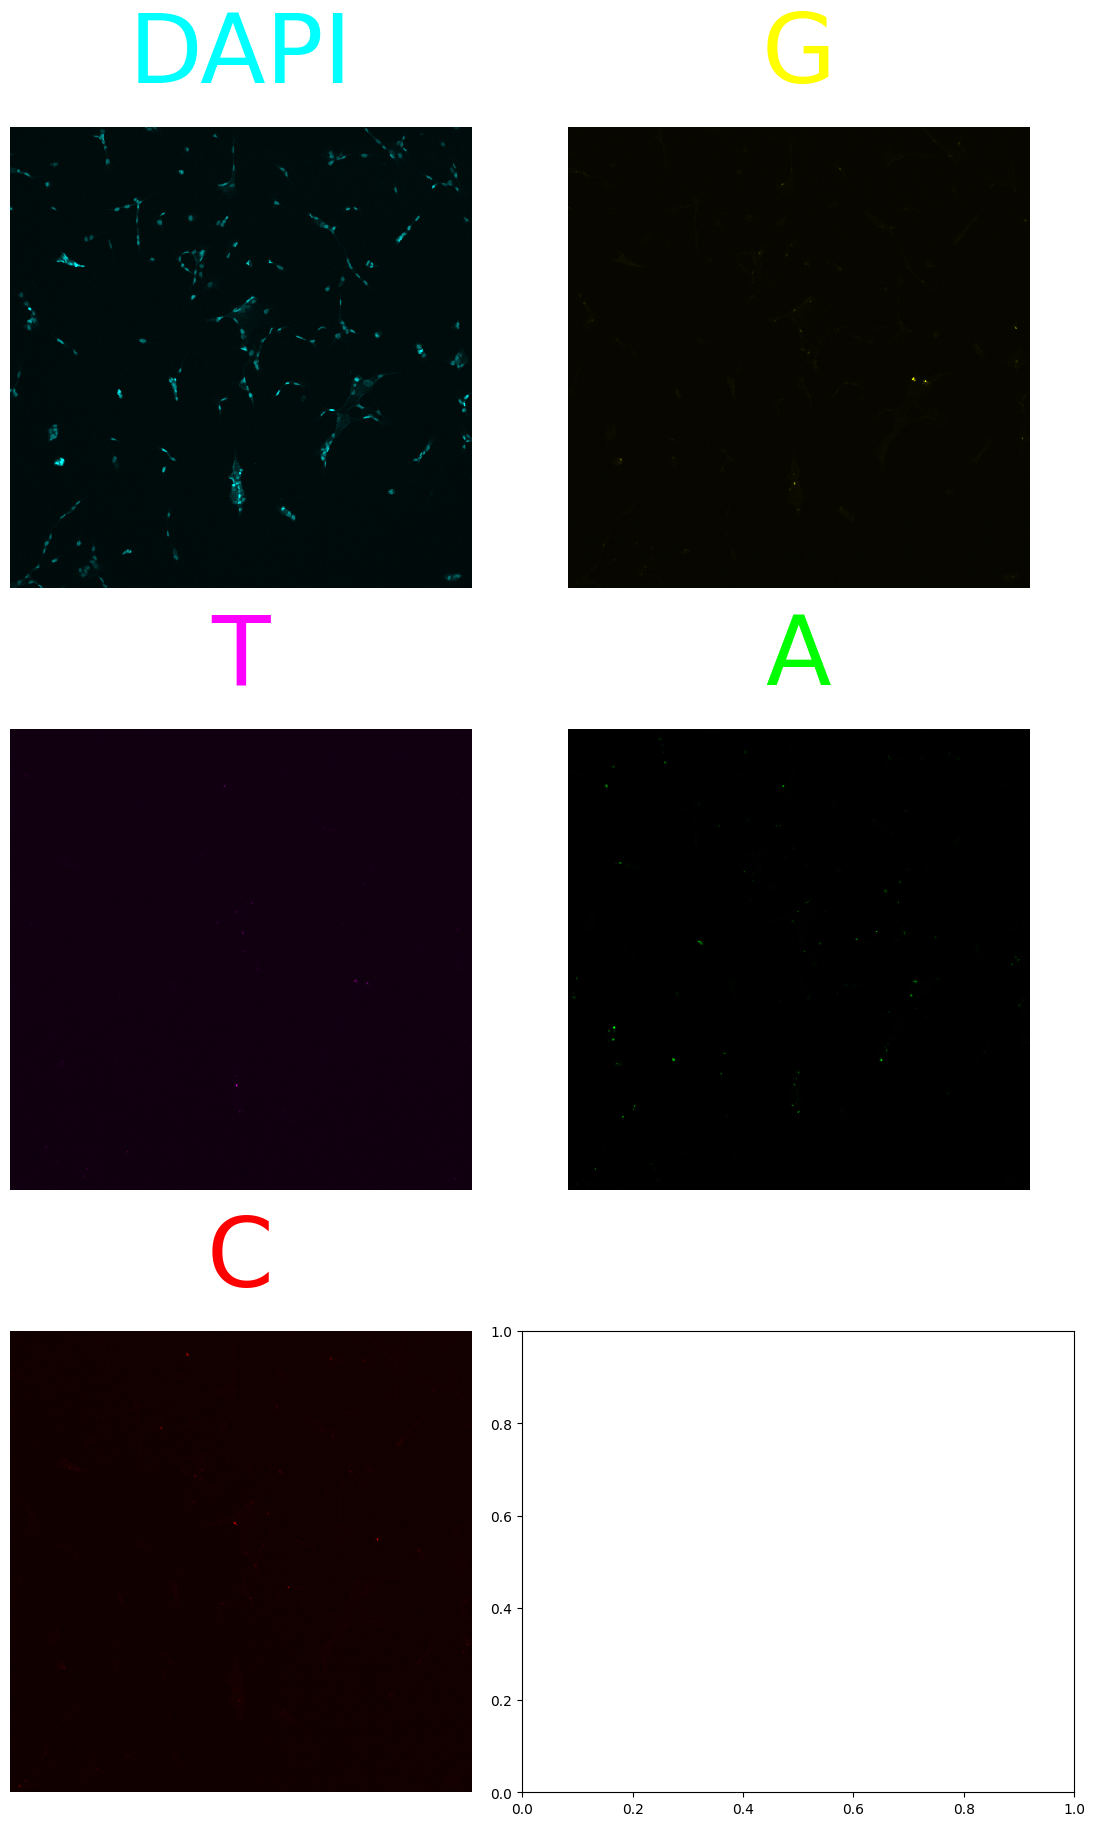


OPTIONAL: Uncomment the code below to view all aligned cycles

EXPERIMENTAL: Testing different resize methods
Uncomment sections below to test different resize strategies:

Alignment testing complete!


In [5]:
# load config file
with open(CONFIG_FILE_PATH, "r") as config_file:
    config = yaml.safe_load(config_file)

# Get paths to the sample files dfs
SBS_SAMPLES_FP = Path(config["preprocess"]["sbs_samples_fp"])
# Load the sample TSV files with pandas
sbs_samples = pd.read_csv(SBS_SAMPLES_FP, sep="\t")
SBS_CYCLES = sorted(list(sbs_samples["cycle"].unique()))
# Define cycles for testing if not None
SKIP_CYCLES_INDICES = [SBS_CYCLES.index(c) for c in SKIP_CYCLES] if SKIP_CYCLES is not None else None
MANUAL_BACKGROUND_CYCLE_INDEX = SBS_CYCLES.index(MANUAL_BACKGROUND_CYCLE) if MANUAL_BACKGROUND_CYCLE is not None else None

# load test image data
print("Loading test images...")
ROOT_FP = Path("/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/")
PREPROCESS_FP = ROOT_FP / "preprocess"
sbs_test_image_paths = expand(
    PREPROCESS_FP
    / "images"
    / "sbs"
    / get_filename(
        {"plate": TEST_PLATE, "well": TEST_WELL, "tile": TEST_TILE, "cycle": "{cycle}"},
        "image",
        "tiff",
    ),
    cycle=SBS_CYCLES,
)
sbs_test_images = [imread(file_path) for file_path in sbs_test_image_paths]

# Check image shapes before alignment
print("Image shapes before alignment:")
for i, img in enumerate(sbs_test_images):
    print(f"  Cycle {SBS_CYCLES[i]}: {img.shape}")

# align cycles with resize functionality
print("\nAligning test images with resize handling...")
aligned = align_cycles(
    sbs_test_images,
    channel_order=CHANNEL_NAMES,
    method=ALIGNMENT_METHOD,
    upsample_factor=1,
    use_align_within_cycle=False,
    skip_cycles=SKIP_CYCLES_INDICES,
    manual_background_cycle=MANUAL_BACKGROUND_CYCLE_INDEX,
    resize_cycles=True,  # Enable resizing
    target_spatial_shape=None,  # Auto-determine target shape
    resize_method='downsample_majority',  # Resize to most common smaller size
)

print(f"\nFinal aligned shape: {aligned.shape}")

# Create and display micropanel of aligned images
print("Example aligned image for first cycle:")
aligned_microimages = [
    Microimage(
        aligned[0, i, :, :], channel_names=CHANNEL_NAMES[i], cmaps=CHANNEL_CMAPS[i]
    )
    for i in range(aligned.shape[1])
]
aligned_panel = create_micropanel(aligned_microimages, add_channel_label=True)
plt.show()

# Display comparison of original vs aligned for the mismatched cycle
# Find which cycle was resized (if any)
original_shapes = [img.shape for img in sbs_test_images]
if not SKIP_CYCLES_INDICES:
    processed_shapes = original_shapes
else:
    processed_shapes = [original_shapes[i] for i in range(len(original_shapes)) if i not in SKIP_CYCLES_INDICES]

unique_shapes = list(set([shape[-2:] for shape in processed_shapes]))
if len(unique_shapes) > 1:
    print(f"\nFound cycles with different spatial shapes: {unique_shapes}")
    
    # Find the cycle that was likely resized (largest original shape)
    largest_shape = max(unique_shapes, key=lambda s: s[0] * s[1])
    target_shape = aligned.shape[-2:]
    
    if largest_shape != target_shape:
        print(f"Cycle with shape {largest_shape} was resized to {target_shape}")
        
        # Find which cycle index this corresponds to
        resized_cycle_idx = None
        for i, img in enumerate(sbs_test_images):
            if i not in (SKIP_CYCLES_INDICES or []) and img.shape[-2:] == largest_shape:
                # Convert to aligned array index (accounting for skipped cycles)
                aligned_idx = i
                if SKIP_CYCLES_INDICES:
                    aligned_idx = i - sum(1 for skip in SKIP_CYCLES_INDICES if skip < i)
                resized_cycle_idx = aligned_idx
                break
        
        if resized_cycle_idx is not None and resized_cycle_idx < aligned.shape[0]:
            print(f"\nShowing before/after comparison for resized cycle (aligned index {resized_cycle_idx}):")
            
            # Show aligned version
            print("After resizing and alignment:")
            aligned_microimages = [
                Microimage(
                    aligned[resized_cycle_idx, i, :, :], 
                    channel_names=CHANNEL_NAMES[i], 
                    cmaps=CHANNEL_CMAPS[i]
                )
                for i in range(aligned.shape[1])
            ]
            aligned_panel = create_micropanel(aligned_microimages, add_channel_label=True)
            plt.show()

# Optional: Display all cycles to verify alignment quality
print("\n" + "="*50)
print("OPTIONAL: Uncomment the code below to view all aligned cycles")
print("="*50)

# NOTE: You can also loop through all your cycles to display micropanels to be sure of alignment by uncommenting the following lines:
# print("Displaying all aligned cycles...")
# for cycle_idx in range(aligned.shape[0]):
#     actual_cycle = [c for i, c in enumerate(SBS_CYCLES) if (SKIP_CYCLES_INDICES is None or i not in SKIP_CYCLES_INDICES)][cycle_idx]
#     print(f"Aligned cycle {cycle_idx} (original cycle {actual_cycle}):")
#     aligned_microimages = [
#         Microimage(
#             aligned[cycle_idx, i, :, :], channel_names=CHANNEL_NAMES[i], cmaps=CHANNEL_CMAPS[i]
#         )
#         for i in range(aligned.shape[1])
#     ]
#     aligned_panel = create_micropanel(aligned_microimages, add_channel_label=True)
#     plt.show()

# Test different resize methods if you want to experiment
print("\n" + "="*50)
print("EXPERIMENTAL: Testing different resize methods")
print("="*50)
print("Uncomment sections below to test different resize strategies:")

# # Test 1: Force resize to specific dimensions
# print("\nTesting resize to specific target shape (1200, 1200):")
# aligned_specific = align_cycles(
#     sbs_test_images,
#     channel_order=CHANNEL_NAMES,
#     method=ALIGNMENT_METHOD,
#     upsample_factor=1,
#     use_align_within_cycle=False,
#     skip_cycles=SKIP_CYCLES_INDICES,
#     manual_background_cycle=MANUAL_BACKGROUND_CYCLE_INDEX,
#     resize_cycles=True,
#     target_spatial_shape=(1200, 1200),
# )
# print(f"Result shape: {aligned_specific.shape}")

# # Test 2: Upsample to largest size
# print("\nTesting upsample to largest size:")
# aligned_upsample = align_cycles(
#     sbs_test_images,
#     channel_order=CHANNEL_NAMES,
#     method=ALIGNMENT_METHOD,
#     upsample_factor=1,
#     use_align_within_cycle=False,
#     skip_cycles=SKIP_CYCLES_INDICES,
#     manual_background_cycle=MANUAL_BACKGROUND_CYCLE_INDEX,
#     resize_cycles=True,
#     resize_method='largest',
# )
# print(f"Result shape: {aligned_upsample.shape}")

# # Test 3: Disable resizing (this should fail if you have mismatched shapes)
# print("\nTesting with resizing disabled (may fail with mismatched shapes):")
# try:
#     aligned_no_resize = align_cycles(
#         sbs_test_images,
#         channel_order=CHANNEL_NAMES,
#         method=ALIGNMENT_METHOD,
#         upsample_factor=1,
#         use_align_within_cycle=False,
#         skip_cycles=SKIP_CYCLES_INDICES,
#         manual_background_cycle=MANUAL_BACKGROUND_CYCLE_INDEX,
#         resize_cycles=False,
#     )
#     print(f"Result shape: {aligned_no_resize.shape}")
# except Exception as e:
#     print(f"Failed as expected: {e}")

print("\nAlignment testing complete!")

## <font color='red'>SET PARAMETERS</font>

### Spot detection

- `MAX_FILTER_WIDTH`: Width parameter used for determining the neighborhood size for finding local maxima. No default value, but `3` is suggested
- `SPOT_DETECTION_METHOD`: Methodology for calling spots: 
    - `STANDARD`: Standard method for calling spots, involving Laplacian of Gaussian correction, and computation of spots across cycles. Spots are identified based on signal intensity and consistency across cycles.
        - `PEAK_WIDTH`: Width parameter used for peak detection, sets neighborhood size for finding local maxima of base channels standard deviation. Defaults to `5`
    - `SPOTIFLOW`: Deep learning based methodology for calling spots. Spots are called independently on all 4 bases of a selected cycle, and then coalesced to ensure minimum distance between spots. If this method is selected, the following parameters are required:
        - `SPOTIFLOW_CYCLE_INDEX`: Cycle to use for spot detection
        - `SPOTIFLOW_MODEL`: Model to use for spot detection (e.g., "general", "hybiss")
        - `SPOTIFLOW_THRESHOLD`: Probability threshold for confidence in spot detection
        - `SPOTIFLOW_MIN_DISTANCE`: Minimum distance (in pixels) required between detected spots


In [6]:
# Set parameters:
MAX_FILTER_WIDTH = 3
SPOT_DETECTION_METHOD = "standard"

if SPOT_DETECTION_METHOD == "standard":
   PEAK_WIDTH = 5

elif SPOT_DETECTION_METHOD == "spotiflow":
   SPOTIFLOW_CYCLE_INDEX = 3
   SPOTIFLOW_MODEL = "general"
   SPOTIFLOW_THRESHOLD = 0.75        
   SPOTIFLOW_MIN_DISTANCE = 10

# Derive extra channel indices
EXTRA_CHANNEL_INDICES = [CHANNEL_NAMES.index(channel) for channel in EXTRA_CHANNELS]

Detecting candidate reads...
Applying Laplacian-of-Gaussian (LoG) filter...
Applying max filter...
Computing standard deviation over cycles...
Finding peaks using standard method...
Example max filtered image for first cycle:


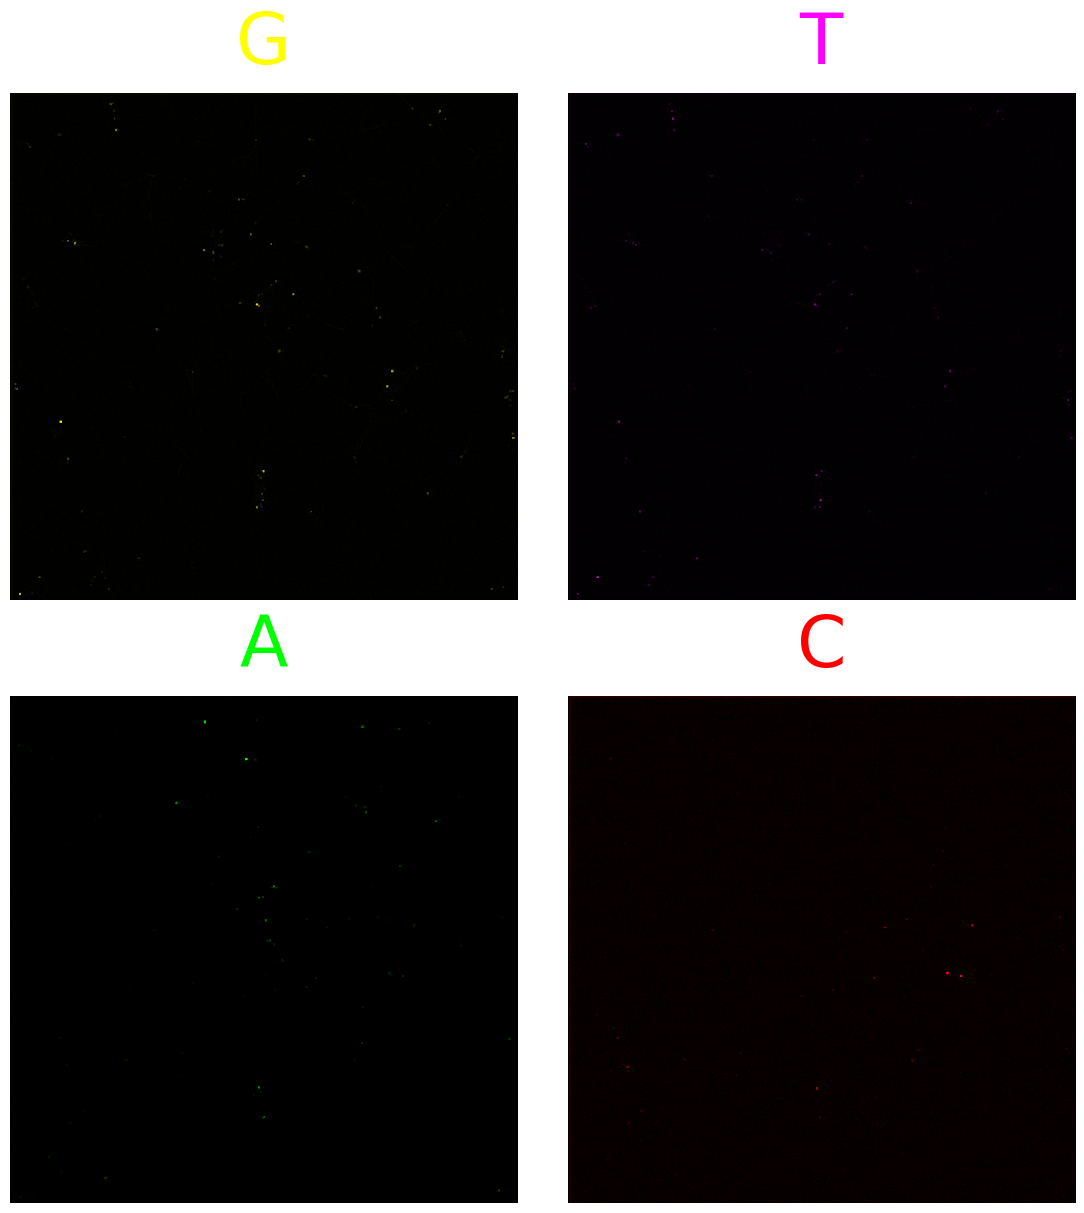

Found 389 peaks above threshold 150


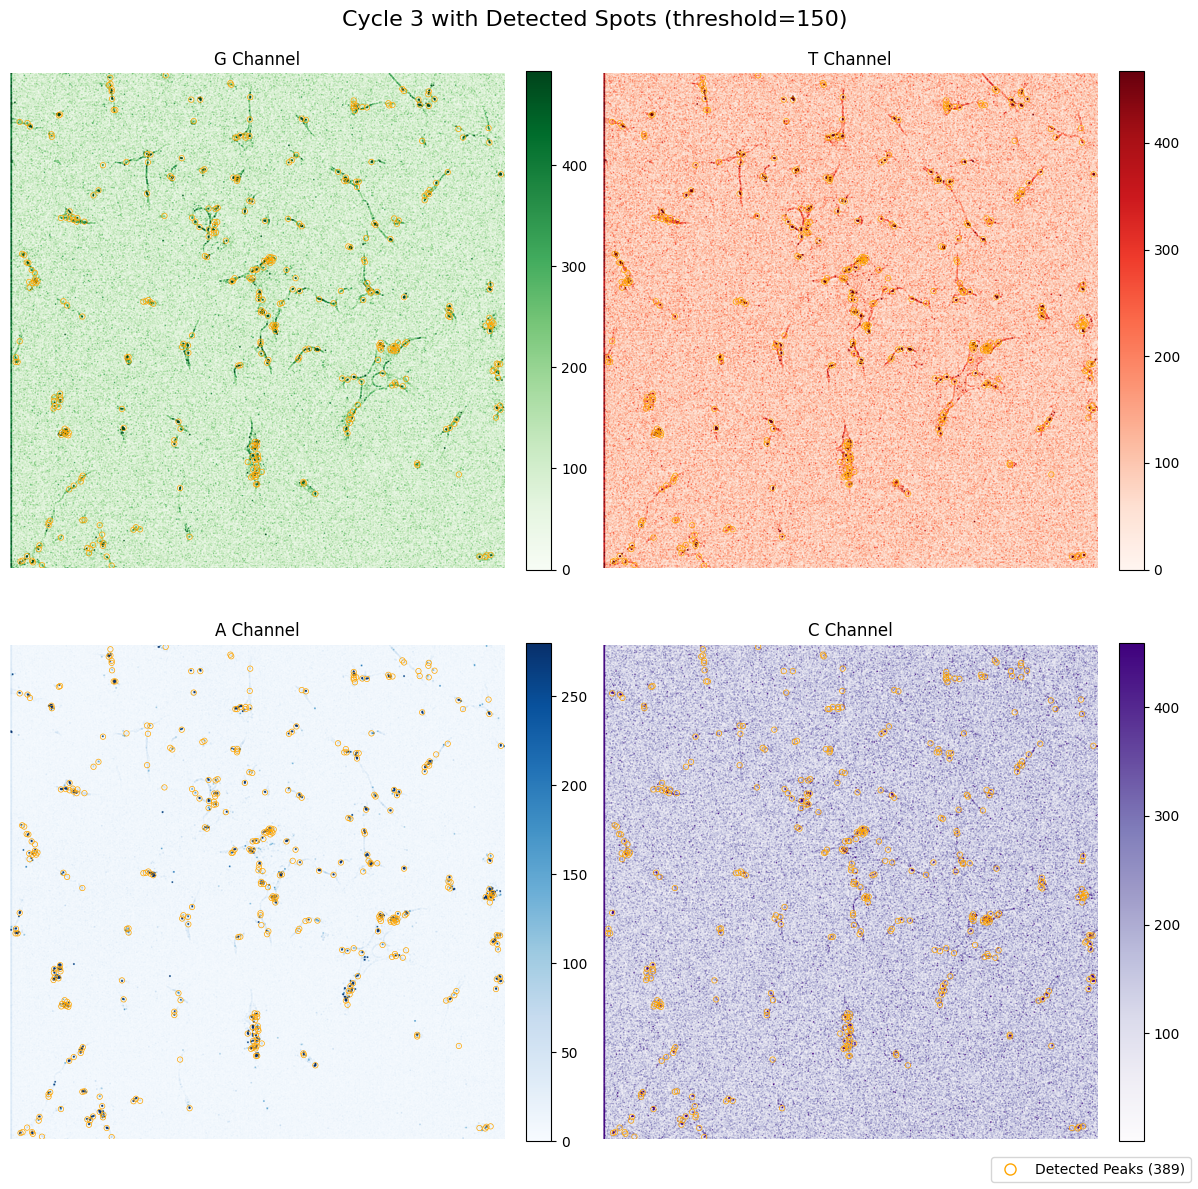

In [7]:
print("Detecting candidate reads...")

print("Applying Laplacian-of-Gaussian (LoG) filter...")
loged = log_filter(aligned, skip_index=EXTRA_CHANNEL_INDICES)

print("Applying max filter...")
maxed = max_filter(loged, width=MAX_FILTER_WIDTH, remove_index=EXTRA_CHANNEL_INDICES)

if SPOT_DETECTION_METHOD == "standard":
    print("Computing standard deviation over cycles...")
    standard_deviation = compute_standard_deviation(loged, remove_index=EXTRA_CHANNEL_INDICES)
    
    print("Finding peaks using standard method...")
    peaks = find_peaks(standard_deviation, width=PEAK_WIDTH)
    
elif SPOT_DETECTION_METHOD == "spotiflow":
    print(f"Finding peaks using Spotiflow (model: {SPOTIFLOW_MODEL})...")
    peaks, _ = find_peaks_spotiflow(
        aligned_images=aligned, 
        cycle_idx=SPOTIFLOW_CYCLE_INDEX,
        model=SPOTIFLOW_MODEL,
        prob_thresh=SPOTIFLOW_OLD,
        min_distance=SPOTIFLOW_MIN_DISTANCE,
        verbose=True
    )

# Create and display micropanel of max filtered datas
print("Example max filtered image for first cycle:")
maxed_microimages = [
    Microimage(maxed[1, i, :, :], channel_names=BASES[i], cmaps=CHANNEL_CMAPS[i + 1])
    for i in range(maxed.shape[1])
]
maxed_panel = create_micropanel(maxed_microimages, add_channel_label=True)
plt.show()

# Plot spots on base channels
fig, axes = plot_channels_with_peaks(
    maxed,                 
    peaks,
    BASES,        
    cycle_number=3,   
    threshold_peaks=150 if SPOT_DETECTION_METHOD == "standard" else None,
    peak_colors=['orange'],
    peak_labels=['Detected Peaks']
)
plt.show()

## <font color='red'>SET PARAMETERS</font>

### Illumination Correction and Segmentation

- `DAPI_CYCLE`: Cycle number where DAPI was imaged. Used for illumination correction of the DAPI channel.
- `CYTO_CYCLE`: Cycle number where the cytoplasmic/background channel was imaged. Used for illumination correction of the cytoplasmic channel.
- `CYTO_CHANNEL`: The name of the cytoplasmic channel used for cell boundary detection. 
  - When `DAPI_CYCLE == CYTO_CYCLE`: Can be any channel imaged in that cycle (e.g., "Vimentin", "GFP", "Phalloidin")
  - When `DAPI_CYCLE != CYTO_CYCLE`: Should be a base channel ("G", "T", "A", or "C") since DAPI was imaged separately

**Note**: Only set `DAPI_CYCLE != CYTO_CYCLE` when DAPI was imaged in a separate cycle from your cytoplasmic signal. This typically occurs when using a base channel (G, T, A, C) for cytoplasm detection because no cellular stain was available in the DAPI cycle.

In [8]:
# Define cycle to use for segmentation
DAPI_CYCLE = 1
CYTO_CYCLE = 1
# Define cytoplasmic channel
CYTO_CHANNEL = "G"

# Derive DAPI and CYTO indexes
DAPI_INDEX = CHANNEL_NAMES.index("DAPI")
CYTO_INDEX = CHANNEL_NAMES.index(CYTO_CHANNEL)
CYTO_CYCLE_INDEX = SBS_CYCLES.index(CYTO_CYCLE) - len([skip for skip in (SKIP_CYCLES or []) if skip < SBS_CYCLES.index(CYTO_CYCLE)])

# Validate DAPI and CYTO cycles and channels
if DAPI_CYCLE != CYTO_CYCLE and CYTO_CHANNEL not in BASES:
    raise ValueError(
        f"When DAPI_CYCLE ({DAPI_CYCLE}) != CYTO_CYCLE ({CYTO_CYCLE}), "
        f"CYTO_CHANNEL should be a base channel {BASES}, but got '{CYTO_CHANNEL}'. "
        f"If using a cellular stain, set DAPI_CYCLE = CYTO_CYCLE."
    )

Applying illumination correction to segmentation cycle image...
Pre-segmentation images:


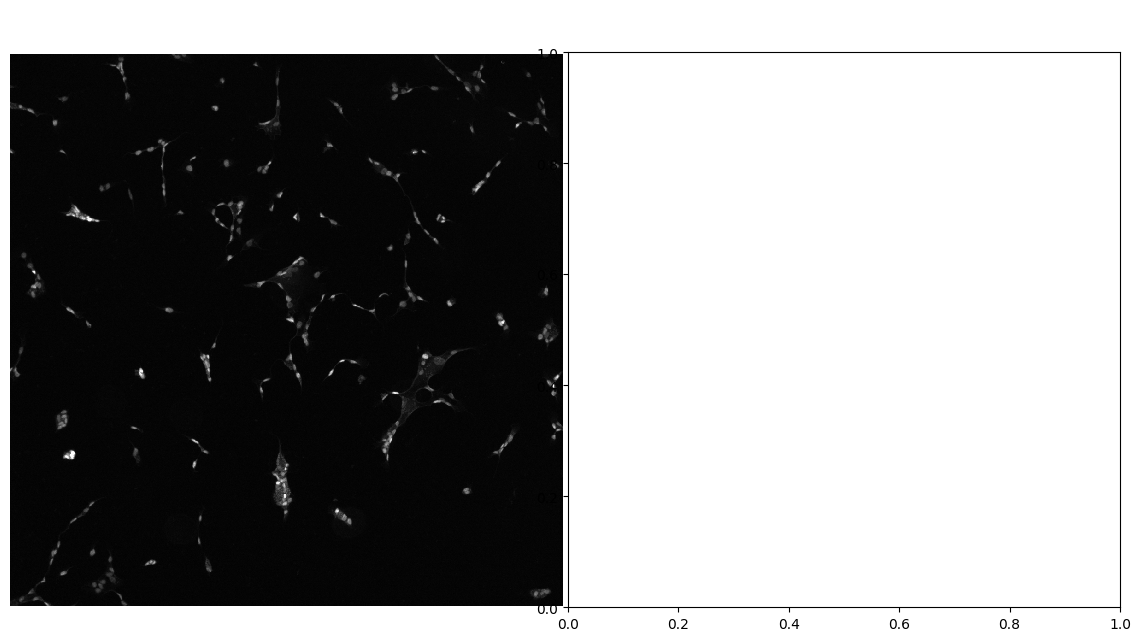

In [9]:
# Determine the cycle to use for segmentation as the cyt
aligned_image_data_segmentation_cycle = aligned[CYTO_CYCLE_INDEX]

print("Applying illumination correction to segmentation cycle image...")

# Logic based on whether DAPI and CYTO come from same or different cycles
if DAPI_CYCLE != CYTO_CYCLE:
    # Different cycles - need to combine IC fields
    ic_field_dapi = imread(
        PREPROCESS_FP / "ic_fields" / "sbs" / 
        get_filename({"plate": TEST_PLATE, "well": TEST_WELL, "cycle": DAPI_CYCLE}, "ic_field", "tiff")
    )
    ic_field_cyto = imread(
        PREPROCESS_FP / "ic_fields" / "sbs" / 
        get_filename({"plate": TEST_PLATE, "well": TEST_WELL, "cycle": CYTO_CYCLE}, "ic_field", "tiff")
    )
    # Combine IC fields - need to figure out the right indices for combine_ic_images
    ic_field = combine_ic_images([ic_field_dapi, ic_field_cyto], [EXTRA_CHANNEL_INDICES, None])
else:
    # Same cycle - use one IC field
    ic_field = imread(
        PREPROCESS_FP / "ic_fields" / "sbs" / 
        get_filename({"plate": TEST_PLATE, "well": TEST_WELL, "cycle": DAPI_CYCLE}, "ic_field", "tiff")
    )

# Apply illumination correction field
corrected_image = apply_ic_field(
    aligned_image_data_segmentation_cycle, correction=ic_field
)

# Prepare corrected image for CellPose segmentation
# NOTE: this process is done during the `segment_cellpose`` method below as well
# Use the prepared_cellpose image to test CellPose (see below)
# print("Preparing IC segmentation image for CellPose...")
# cellpose_rgb = prepare_cellpose(
#     corrected_image,
#     DAPI_INDEX,
#     CYTO_INDEX,
# )

# show max filtered data for one round
print("Pre-segmentation images:")
pre_seg_microimages = [
    Microimage(corrected_image[0], channel_names="Dapi"),
]
pre_seg_panel = create_micropanel(pre_seg_microimages, add_channel_label=True)
plt.show()

## <font color='red'>SET PARAMETERS</font>

### Segmentation

#### Select Segmentation Method
- `SEGMENTATION_METHOD`: Choose from "cellpose", "microsam", "stardist", or "watershed" for cell segmentation.

#### Common Parameters
- `GPU`: Set to True to use GPU acceleration (if available).
- `RECONCILE`: Method for reconciling nuclei and cell masks (typically "contained_in_cells", which allows more than one nucleus per cell and is useful for cells that are dividing).
- `SEGMENT_CELLS`: Whether to segment cells, or only segment nuclei. If spots are contained in nuclei, there is no need to segment cell bodies. This may speed up analysis.

#### Cellpose Parameters (if using "cellpose")
- `CELLPOSE_MODEL`: CellPose model to use ("cyto", "cyto2", or "cyto3"). Default is "cyto3".
- `CELL_FLOW_THRESHOLD` & `NUCLEI_FLOW_THRESHOLD`: Flow threshold for Cellpose segmentation. Default is 0.4.
- `CELL_CELLPROB_THRESHOLD` & `NUCLEI_CELLPROB_THRESHOLD`: Cell probability threshold for Cellpose. Default is 0.
- Note: Nuclei and cell diameters will be estimated automatically, but can be manually overridden.

#### MicroSAM Parameters (if using "microsam")
- `MICROSAM_MODEL`: MicroSAM model type. Default is "vit_b_lm".

#### StarDist Parameters (if using "stardist")
- `STARDIST_MODEL`: StarDist model type. Default is "2D_versatile_fluo".
- `CELL_PROB_THRESHOLD` & `NUCLEI_PROB_THRESHOLD`: Probability threshold for segmentation. Default is 0.479071.
- `CELL_NMS_THRESHOLD` & `NUCLEI_NMS_THRESHOLD`: Non-maximum suppression threshold. Default is 0.3.

#### Watershed Parameters (if using "watershed")
- `THRESHOLD_DAPI`: Threshold for nuclei segmentation. 
- `THRESHOLD_CELL`: Threshold for cell boundary segmentation.
- `NUCLEUS_AREA`: Range for filtering nuclei by area as a tuple (min, max).

Note: You may want to adjust these parameters and run segmentation tests if you feel you are capturing too little or too much area for the masks. For cellpose, the nuclei and cell diameters will be automatically estimated, but can be manually adjusted if needed.

In [10]:
# Select segmentation method
SEGMENTATION_METHOD = "watershed"

# Common parameters
GPU = False
# RECONCILE = "contained_in_cells"
SEGMENT_CELLS = False
NUCLEI_DIAMETER = 10
CELL_DIAMETER = 30

if SEGMENTATION_METHOD == "cellpose":
    # Parameters for CellPose method
    CELLPOSE_MODEL = "cpsam"
    NUCLEI_FLOW_THRESHOLD = 0.3
    NUCLEI_CELLPROB_THRESHOLD = 1
    CELL_FLOW_THRESHOLD = 1 
    CELL_CELLPROB_THRESHOLD = 0 


elif SEGMENTATION_METHOD == "microsam":
    # Parameters for MicroSAM method
    MICROSAM_MODEL = "vit_b_lm"

elif SEGMENTATION_METHOD == "stardist":
    # Parameters for StarDist method
    STARDIST_MODEL = "2D_versatile_fluo"
    NUCLEI_PROB_THRESHOLD = 0.479071
    NUCLEI_NMS_THRESHOLD = 0.3
    CELL_PROB_THRESHOLD = 0.479071
    CELL_NMS_THRESHOLD = 0.3

elif SEGMENTATION_METHOD == "watershed":
    # Parameters for Watershed method
    THRESHOLD_DAPI = 470  
    THRESHOLD_CELL = 1300
    NUCLEUS_AREA = (70, 800)
    LOG_TRANSFORM = False

Segmenting image with watershed...
Number of nuclei segmented: 301
Example microplots for DAPI channel and nuclei segmentation:


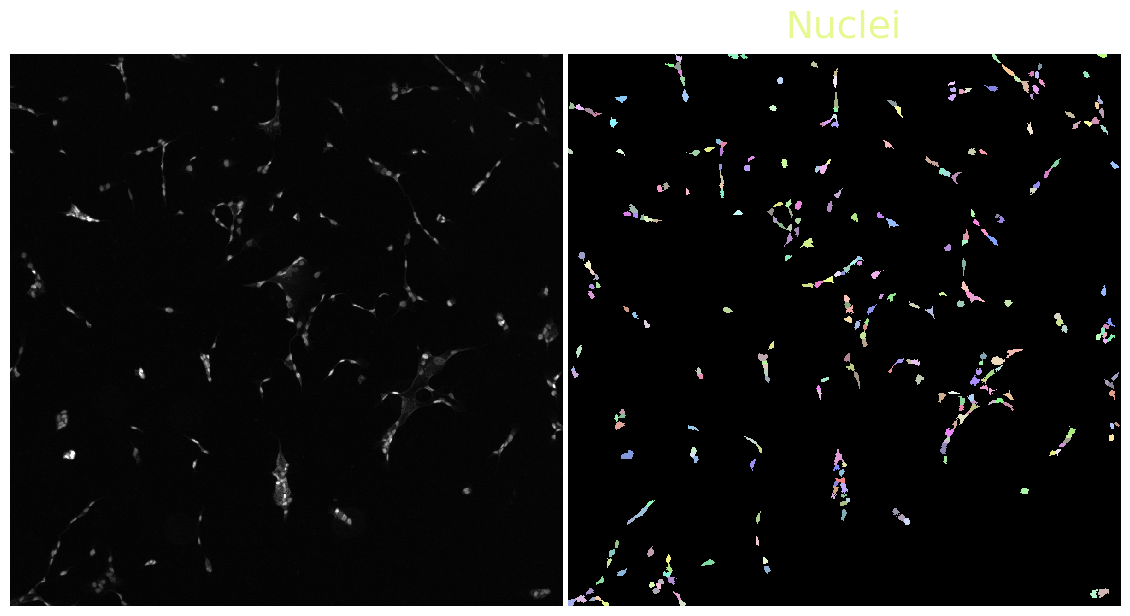

Example microplot for sequencing data annotated with segmentation:


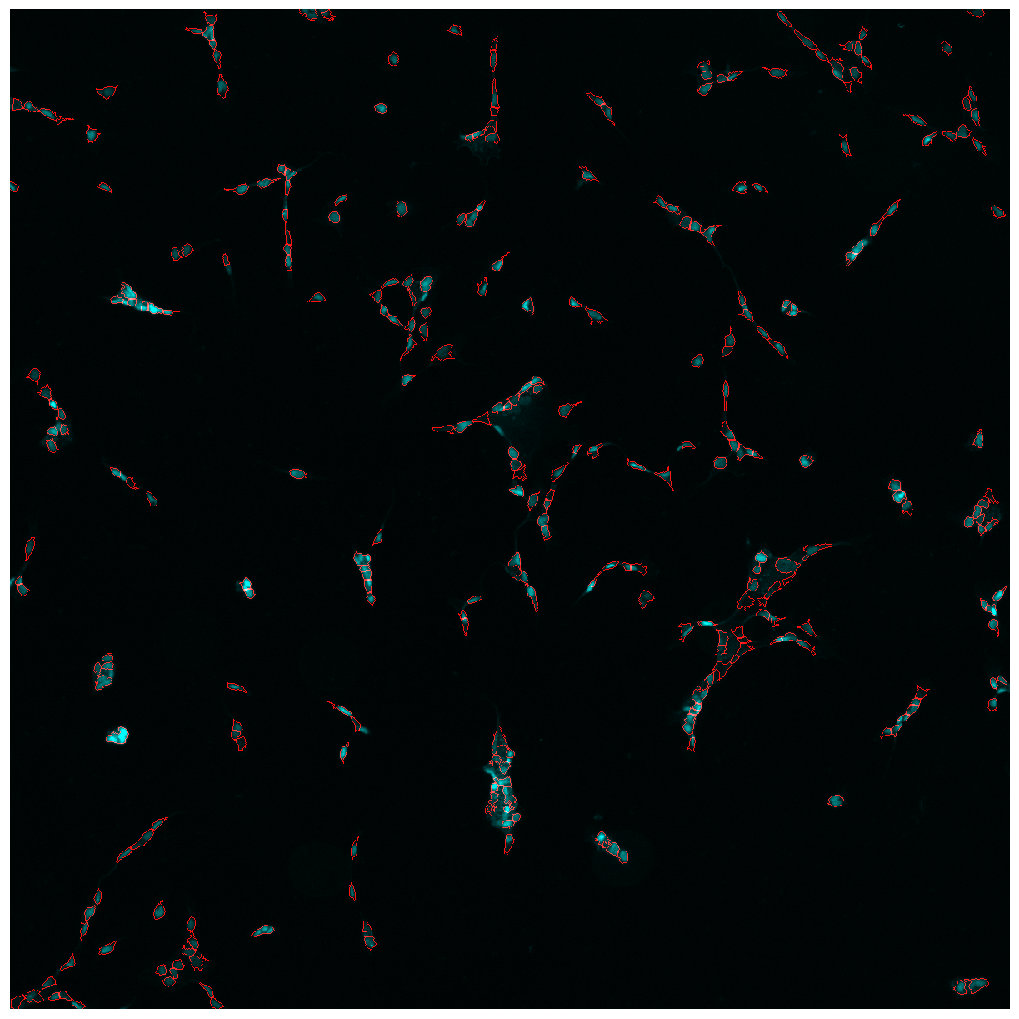

In [11]:
print(f"Segmenting image with {SEGMENTATION_METHOD}...")

if SEGMENTATION_METHOD == "cellpose":
    from lib.shared.segment_cellpose import segment_cellpose
    nuclei, cells = segment_cellpose(
        corrected_image,
        dapi_index=DAPI_INDEX,
        cyto_index=CYTO_INDEX,
        helper_index=3,
        nuclei_diameter=NUCLEI_DIAMETER,
        cell_diameter=CELL_DIAMETER,
        cellpose_kwargs=dict(
            nuclei_flow_threshold=NUCLEI_FLOW_THRESHOLD,
            nuclei_cellprob_threshold=NUCLEI_CELLPROB_THRESHOLD,
            cell_flow_threshold=CELL_FLOW_THRESHOLD,
            cell_cellprob_threshold=CELL_CELLPROB_THRESHOLD,
        ),
        cyto_model=CELLPOSE_MODEL,
        gpu=True,
        reconcile=RECONCILE,
    )

elif SEGMENTATION_METHOD == "microsam":
    from lib.shared.segment_microsam import segment_microsam
    nuclei, cells = segment_microsam(
        corrected_image,
        dapi_index=DAPI_INDEX,
        cyto_index=CYTO_INDEX,
        model_type=MICROSAM_MODEL,
        gpu=GPU,
        reconcile=RECONCILE,
        cells=SEGMENT_CELLS,
    )

elif SEGMENTATION_METHOD == "stardist":
    from lib.shared.segment_stardist import segment_stardist
    nuclei, cells = segment_stardist(
        corrected_image,
        dapi_index=DAPI_INDEX,
        cyto_index=CYTO_INDEX,
        model_type=STARDIST_MODEL,
        stardist_kwargs=dict(
            nuclei_prob_threshold=NUCLEI_PROB_THRESHOLD,
            nuclei_nms_threshold=NUCLEI_NMS_THRESHOLD,
            cell_prob_threshold=CELL_PROB_THRESHOLD,
            cell_nms_threshold=CELL_NMS_THRESHOLD,
        ),
        gpu=GPU,
        reconcile=RECONCILE,
        cells=SEGMENT_CELLS,
    )

elif SEGMENTATION_METHOD == "watershed":
    from lib.shared.segment_watershed import segment_watershed
    nuclei = segment_watershed(
        corrected_image,
        nuclei_threshold=THRESHOLD_DAPI,
        nuclei_area_min=NUCLEUS_AREA[0],
        nuclei_area_max=NUCLEUS_AREA[1],
        cell_threshold=THRESHOLD_CELL,
        cells=SEGMENT_CELLS,
        log_transform=LOG_TRANSFORM,
    )

cells = np.zeros_like(nuclei)

# Create and display micropanel of nuclei segmention
print("Example microplots for DAPI channel and nuclei segmentation:")
nuclei_cmap = random_cmap(num_colors=len(np.unique(nuclei)))
nuclei_seg_microimages = [
    Microimage(corrected_image[0], channel_names="Dapi"),
    Microimage(nuclei, cmaps=nuclei_cmap, channel_names="Nuclei"),
]
nuclei_seg_panel = create_micropanel(nuclei_seg_microimages, add_channel_label=True)
plt.show()

# # Create and display micropanel of segmented cells
# print("Example microplots for merged channels and cells segmentation:")
# cells_cmap = random_cmap(num_colors=len(np.unique(cells)))
# cells_seg_microimages = [
#     Microimage(cellpose_rgb, channel_names="Merged"),
#     Microimage(cells, cmaps=cells_cmap, channel_names="Cells"),
# ]
# cells_seg_panel = create_micropanel(cells_seg_microimages, add_channel_label=True)
# plt.show()

# Create and display micropanel of annotated data
print("Example microplot for sequencing data annotated with segmentation:")
annotated_data = image_segmentation_annotations(corrected_image[0], nuclei, cells)
annotated_microimage = [
    Microimage(
        annotated_data,
        channel_names="Merged",
        cmaps=["pure_cyan", "pure_red"],
    )
]
annotated_panel = create_micropanel(
    annotated_microimage, num_cols=1, figscaling=10, add_channel_label=False
)
plt.show()

## <font color='red'>SET PARAMETERS</font>

### Barcode Design Table Standardization

Raw barcode design tables from different sources often have inconsistent formatting, column names, and gene annotations. This standardization step transforms your raw design file into a consistent format with validated gene symbols, standardized column names, and proper barcode prefixes. The process includes column renaming, duplicate removal, gene symbol validation (via UniProt), non-targeting control standardization, and barcode prefix generation.

The **most critical parameters** are:  
`PREFIX_MAP`, `PREFIX_RECOMB`, `GENE_SYMBOL_COL`, `GENE_ID_COL`, `MAP_PREFIX_LENGTH`, `RECOMB_PREFIX_LENGTH`, and `SEQUENCING_ORDER`.

### File Paths

- `DF_DESIGN_FP`: Path to raw guide RNA design file.  
- `DF_BARCODE_LIBRARY_FP`: Path to save the cleaned, standardized barcode library.  
- `UNIPROT_DATA_FP`: Temporary path for UniProt annotation data (auto-deleted). Used for gene validation.

### Gene Annotation

- `GENE_SYMBOL_COL`: Column with gene symbols (e.g., `"gene_symbol"`). Set to `None` if not available.  
- `GENE_ID_COL`: Column with gene IDs (e.g., `"gene_id"`). Set to `None` if not available.

### Barcode Columns

- `PREFIX_MAP`: Column name for mapping barcode; renamed to `"prefix_map"`.  
- `PREFIX_RECOMB`: Column name for recombination barcode; renamed to `"prefix_recomb"`.

### Barcode Structure

- `MAP_PREFIX_LENGTH`: Number of sequencing cycles used for mapping barcode.  
- `RECOMB_PREFIX_LENGTH`: Number of sequencing cycles used for recombination barcode.  
- `SKIP_CYCLES_MAP`: List of base positions to skip for mapping (e.g. sequencing cycle 3 for the mapping barcode is out of focus, so we are skipping the nucleotide corresponding to that sequencing cycle). Optional.  
- `SKIP_CYCLES_RECOMB`: List of base positions to skip for recombination. Optional.

### Sequencing Configuration

- `SEQUENCING_ORDER`: Order of barcode sequencing, `"map_recomb"` or `"recomb_map"`.  
- `PREFIX_FUNC`: (Optional) Custom function to generate prefixes from rows. Use for complex barcode layouts.

**Note:**  
You may specify additional options such as filtering functions, prefix generators, and non-targeting control patterns in the `standardize_barcode_design()` call. See the function documentation for examples.


In [14]:
# Define parameters for cleaning up barcode design table
DF_DESIGN_FP = "/lab/ops_analysis/lourido/nebo-analysis/analysis/config/CSM_library_design.20240821-144651.csv"
DF_BARCODE_LIBRARY_FP = "config/barcode_library.tsv"
UNIPROT_DATA_FP = "config/uniprot_data.tsv"
PREFIX_MAP = "iBAR_2" # This barcode will be renamed to prefix_map
PREFIX_RECOMB = "iBAR_1" # This barcode will be renamed to prefix_recomb
GENE_SYMBOL_COL = "target"
GENE_ID_COL = None
MAP_PREFIX_LENGTH = 7 # Number of cycles sequenced for the mapping barcode
RECOMB_PREFIX_LENGTH = 2 # Number of cycles sequenced for the recombination barcode
SKIP_CYCLES_MAP = None
SKIP_CYCLES_RECOMB = None
SEQUENCING_ORDER = "map_recomb" # or "recomb_map"


In [15]:
# Get uniprot data and save it temporarily
uniprot_data = get_uniprot_data()
uniprot_data.to_csv(UNIPROT_DATA_FP, sep="\t", index=False)
uniprot_data = pd.read_csv(UNIPROT_DATA_FP, sep="\t")

# Read and standardize guide data
print("Loading and standardizing barcode design table...")
df_design = pd.read_csv(DF_DESIGN_FP)

# Standardize the barcode design table
df_barcode_library = standardize_barcode_design(
    df_design,
    prefix_map=PREFIX_MAP,
    prefix_recomb=PREFIX_RECOMB,
    gene_symbol_col=GENE_SYMBOL_COL,
    gene_id_col=GENE_ID_COL,
    uniprot_data_path=UNIPROT_DATA_FP,
    map_prefix_length=MAP_PREFIX_LENGTH,
    recomb_prefix_length=RECOMB_PREFIX_LENGTH,
    skip_cycles_map=SKIP_CYCLES_MAP,
    skip_cycles_recomb=SKIP_CYCLES_RECOMB, 
)
# Delete uniprot data file
Path(UNIPROT_DATA_FP).unlink(missing_ok=True)

# Save standardized design table
df_barcode_library.to_csv(DF_BARCODE_LIBRARY_FP, sep="\t", index=False)
print(f"Standardized barcode design saved to: {DF_BARCODE_LIBRARY_FP}")
display(df_barcode_library)

# Extract barcodes (prefixes) for mapping
barcodes = get_barcode_list(df_barcode_library)
print(f"Extracted {len(barcodes)} barcode prefixes for read mapping")

Fetching UniProt data...
Completed. Total entries: 205615
Loading and standardizing barcode design table...
Standardizing barcode design table with 93 entries...
Renamed 'iBAR_2' column to 'prefix_map'
Renamed 'iBAR_1' column to 'prefix_recomb'
Renamed 'target' column to 'gene_symbol'
Modified 'prefix_map' using truncation (length=7)
Modified 'prefix_recomb' using truncation (length=2)
Loaded UniProt data: 205615 entries
Removed 39211 entries without gene names
Processed UniProt data: 53993 unique gene names
UniProt annotation results:
  - 88/93 regular genes successfully annotated
  - 5 unique genes without UniProt annotation:
    ['NTC1', 'NTC2', 'NTC3', 'NTC4', 'NTC5']
  - Consider reviewing these genes or updating gene symbols
Standardized barcode design table:
  - 93 unique barcodes
  - Columns: ['prefix_map', 'gene_symbol', 'uniprot_entry', 'prefix_recomb']
  - Gene symbols: 93 non-empty
  - Unique gene symbols: 49
  - UniProt validated: 88/93 entries
Standardized barcode design 

,prefix_map,gene_symbol,uniprot_entry,prefix_recomb
0,CACCTTA,ATF4,P18848,AA
1,CTTTAGG,ATF4,P18848,AG
2,TGGGTTC,CDKN1A,P38936,AT
3,TCTAGCC,CDKN1A,P38936,GT
4,CACAGAA,COG2,Q14746,AC
...,...,...,...,...
88,CAGAAAG,USP7,Q93009,AG
89,TCTCGGA,VPS4A,Q9UN37,AC
90,CGAATCG,VPS4A,Q9UN37,AT
91,CTTACGA,ZBP1,Q9H171,AA


Extracted 93 barcode prefixes for read mapping


## <font color='red'>SET PARAMETERS</font>

### Extract base intensity, call reads, assign to cells
- `THRESHOLD_READS`: Initial threshold for detecting sequencing reads, set to ~50 for preliminary analysis. This parameter will be optimized based on the mapping rate vs. peak threshold plot generated below. A higher threshold increases confidence in read calls but reduces the total number of detected reads.
- `CALL_READS_METHOD`: Method to use for correcting base intensity across channels. The below `plot_normalization_comparison` function will help you assess what method to use. Options are:
    - `MEDIAN`: Uses median-based correction, performed independently for each tile. This is the default method.
    - `PERCENTILE`: Uses percentile-based correction, performed independently for each tile.

In [ ]:
# Define parameters for calling reads
THRESHOLD_READS = 175
CALL_READS_METHOD = "percentile"


In [ ]:
# Run extract_bases and call_reads with the default threshold
df_bases = extract_bases(
    peaks, maxed, nuclei, THRESHOLD_READS, wildcards=WILDCARDS, bases=BASES
)
df_reads = call_reads(df_bases, peaks_data=peaks, method=CALL_READS_METHOD)

In [ ]:
df_bases

,read,cycle,channel,intensity,cell,i,j,tile,well
36,1,1,G,76,0,6,176,123,A3
37,1,1,T,137,0,6,176,123,A3
38,1,1,A,21,0,6,176,123,A3
39,1,1,C,1,0,6,176,123,A3
40,1,2,G,761,0,6,176,123,A3
...,...,...,...,...,...,...,...,...,...
10975,304,8,C,297,350,1192,558,123,A3
10976,304,9,G,179,350,1192,558,123,A3
10977,304,9,T,117,350,1192,558,123,A3
10978,304,9,A,212,350,1192,558,123,A3


In [ ]:
df_reads

,read,cell,i,j,tile,well,barcode,Q_0,Q_1,Q_2,Q_3,Q_4,Q_5,Q_6,Q_7,Q_8,Q_min,peak
38,1,0,6,176,123,A3,TGTCGACGT,0.788349,0.352914,0.426652,0.278357,0.002354,0.000000,0.913332,0.295788,0.511453,0.000000,465.734422
1442,40,0,220,56,123,A3,TACACTCAC,0.483027,0.249380,0.078535,0.764250,0.216496,0.375603,0.526346,0.032992,0.512862,0.032992,1195.774216
1874,52,0,319,106,123,A3,TTCCGATCT,0.261188,0.105741,0.107360,0.547595,0.502382,0.006761,0.448907,0.043376,0.391927,0.006761,210.426728
2270,63,0,358,770,123,A3,ATCCCTGGT,0.254994,0.367366,0.292689,0.326231,0.251765,0.033056,0.013003,0.334316,0.277831,0.013003,550.644661
2990,83,0,420,35,123,A3,AGAACAAGG,0.897199,0.247491,0.596761,0.490049,0.065162,0.067362,0.047690,0.333231,0.194287,0.047690,256.023995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10730,298,344,1171,652,123,A3,ACTTAGTAG,0.709189,0.057259,0.134813,0.073466,0.160278,0.239309,0.307815,0.185294,0.456637,0.057259,466.392455
10838,301,347,1185,584,123,A3,ATCCGAGAG,1.000000,0.640460,0.432947,0.711616,0.019047,0.041905,0.599147,0.127628,0.467897,0.019047,857.645740
10910,303,348,1190,583,123,A3,ATACGACGG,1.000000,0.037129,0.604087,1.000000,0.947499,0.185481,1.000000,0.328825,0.005648,0.005648,483.305007
10874,302,349,1188,602,123,A3,AGTGAAGAC,1.000000,0.788112,0.729527,0.612980,0.431254,0.253196,0.480159,0.168177,0.304260,0.168177,659.084085


The following plots will help determine the optimal `THRESHOLD_READS` value for your data:

Mapping rate vs. peak threshold for determining optimal peak cutoff:


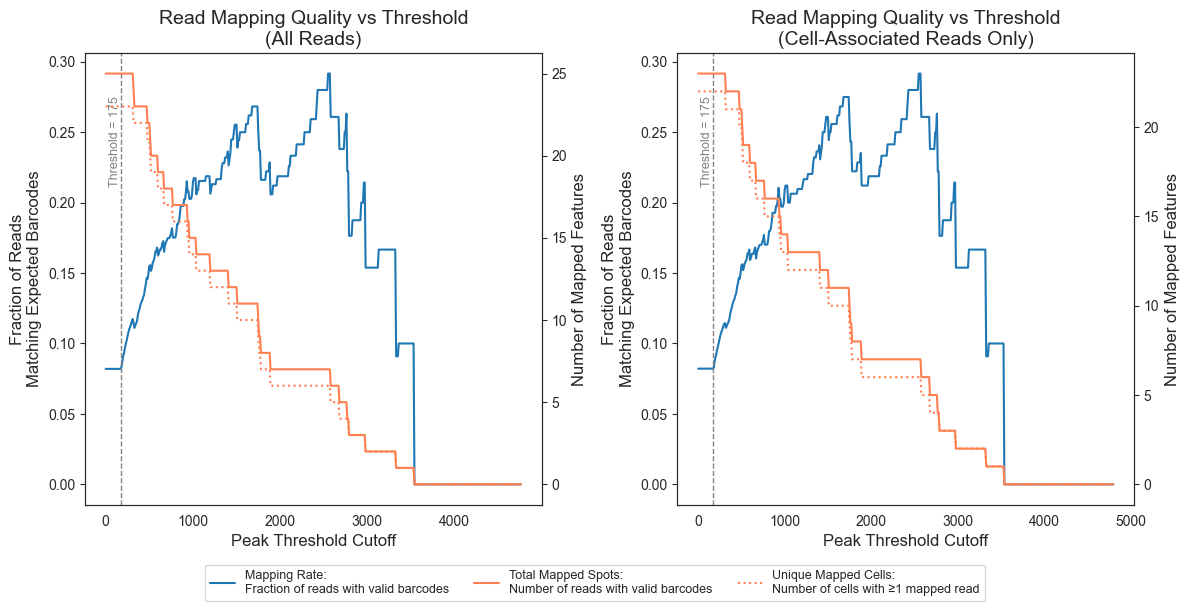

In [ ]:
print("Mapping rate vs. peak threshold for determining optimal peak cutoff:")

df_summary, fig = plot_mapping_vs_threshold(df_reads, barcodes, "peak")

# Access the two subplots (left: all reads, right: cell-associated)
ax1, ax2 = fig.axes[0], fig.axes[1]

# Add vertical line annotation to both axes
threshold_to_annotate = THRESHOLD_READS  

for ax in [ax1, ax2]:
    ax.axvline(threshold_to_annotate, color="gray", linestyle="--", linewidth=1)
    ax.text(
        threshold_to_annotate,
        ax.get_ylim()[1] * 0.9,
        f"Threshold = {threshold_to_annotate}",
        rotation=90,
        va="top",
        ha="right",
        fontsize=9,
        color="gray"
    )


#### Left Plot (All Reads):
- Shows how the peak threshold affects all detected reads
- Blue line: Mapping rate (fraction of reads matching expected barcodes)
- Solid orange line: Total number of mapped spots (reads with valid barcodes)
- Dotted orange line: Number of unique cells with at least one mapped read

#### Right Plot (Cell-Associated Reads Only):
- Shows the same metrics but only for reads associated with cells

#### Setting Threshold Peaks:
Look for the point where the blue line (mapping rate) begins to plateau (~400)
- Consider the trade-off with number of mapped spots and cells
- A threshold around 300-500 typically provides a good balance:
  - Achieves ~75% mapping rate
  - Retains a reasonable number of mapped spots
  - Maintains coverage across cells

In [ ]:
THRESHOLD_READS = 175

Extracted bases:


,read,cycle,channel,intensity,cell,i,j,tile,well
36,1,1,G,76,0,6,176,123,A3
37,1,1,T,137,0,6,176,123,A3
38,1,1,A,21,0,6,176,123,A3
39,1,1,C,1,0,6,176,123,A3
40,1,2,G,761,0,6,176,123,A3
...,...,...,...,...,...,...,...,...,...
10975,304,8,C,297,350,1192,558,123,A3
10976,304,9,G,179,350,1192,558,123,A3
10977,304,9,T,117,350,1192,558,123,A3
10978,304,9,A,212,350,1192,558,123,A3


Base intensity across cycles:


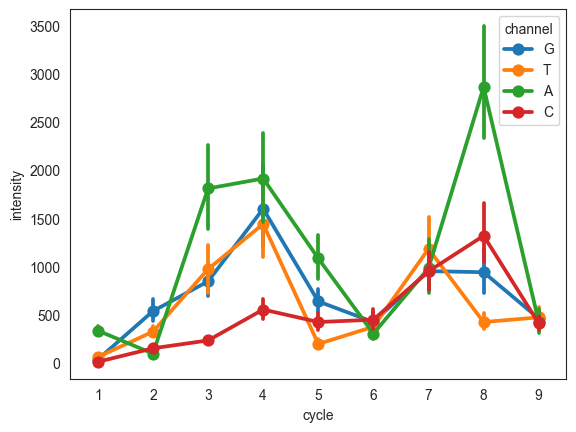

Intensity for each base:


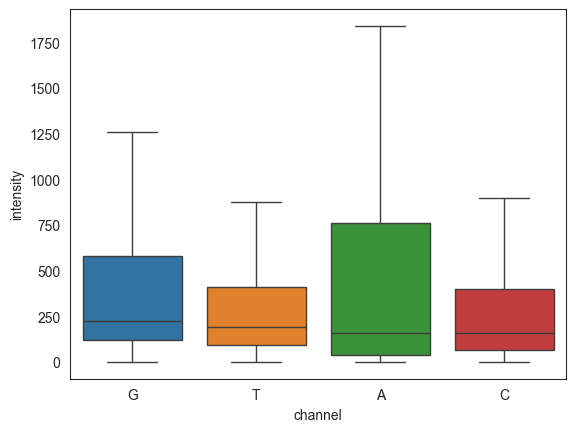

Different normalization methods


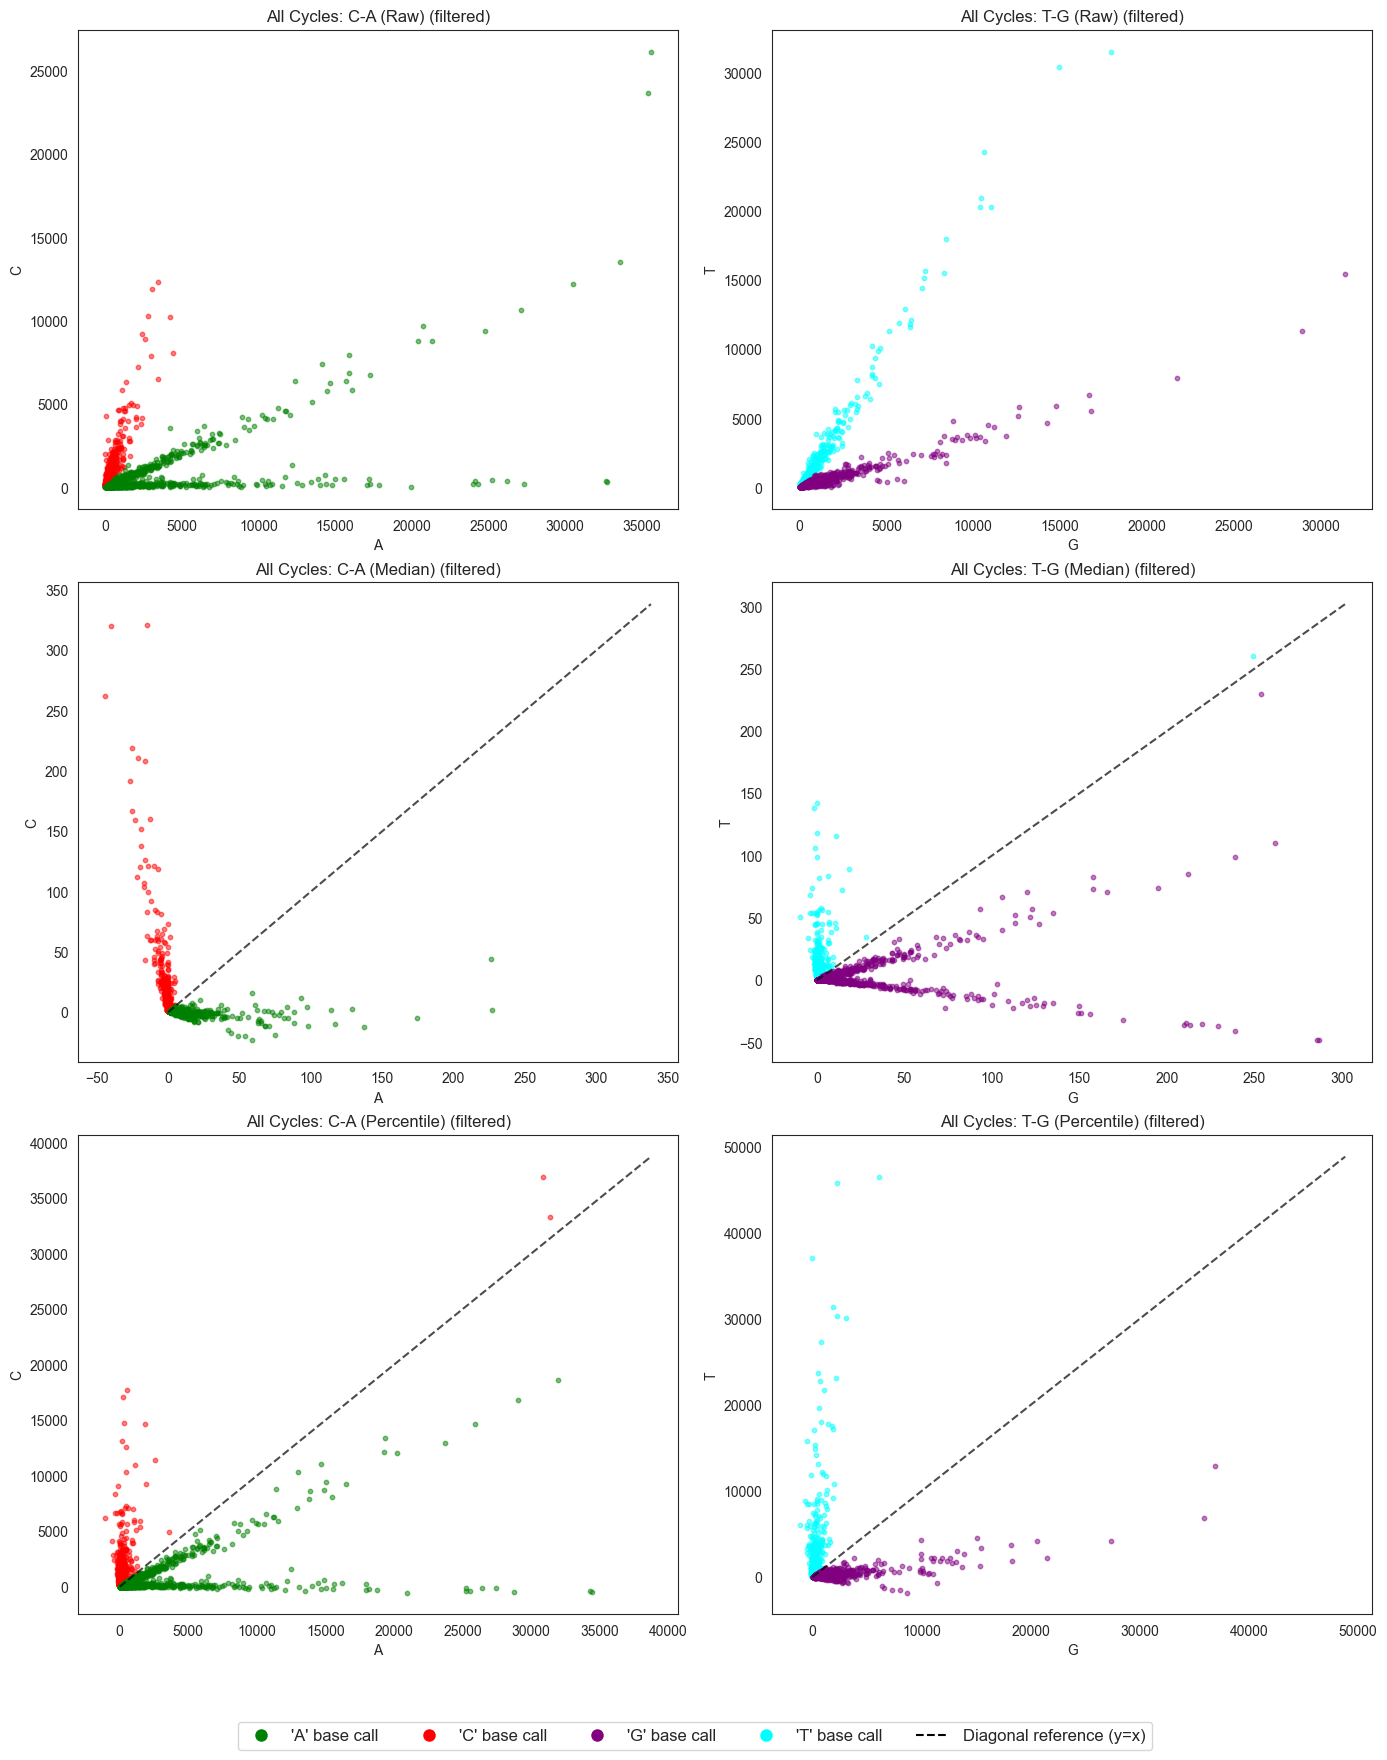

In [ ]:
# Re-run extract_bases and call_reads with the new threshold
print("Extracted bases:")
df_bases = extract_bases(
    peaks, maxed, nuclei, THRESHOLD_READS, wildcards=WILDCARDS, bases=BASES
)
display(df_bases)

print("Base intensity across cycles:")
ax = sns.pointplot(x="cycle", y="intensity", hue="channel", data=df_bases)
plt.show()

print("Intensity for each base:")
ax = sns.boxplot(
    x="channel", y="intensity", hue="channel", data=df_bases, showfliers=False
)
plt.show()

print("Different normalization methods")
plot_normalization_comparison(df_bases, base_order = BASES)

In [ ]:
print("Called reads:")
df_reads = call_reads(df_bases, peaks_data=peaks, method=CALL_READS_METHOD)
display(df_reads)

Called reads:


,read,cell,i,j,tile,well,barcode,Q_0,Q_1,Q_2,Q_3,Q_4,Q_5,Q_6,Q_7,Q_8,Q_min,peak
38,1,0,6,176,123,A3,TGTCGACGT,0.788349,0.352914,0.426652,0.278357,0.002354,0.000000,0.913332,0.295788,0.511453,0.000000,465.734422
1442,40,0,220,56,123,A3,TACACTCAC,0.483027,0.249380,0.078535,0.764250,0.216496,0.375603,0.526346,0.032992,0.512862,0.032992,1195.774216
1874,52,0,319,106,123,A3,TTCCGATCT,0.261188,0.105741,0.107360,0.547595,0.502382,0.006761,0.448907,0.043376,0.391927,0.006761,210.426728
2270,63,0,358,770,123,A3,ATCCCTGGT,0.254994,0.367366,0.292689,0.326231,0.251765,0.033056,0.013003,0.334316,0.277831,0.013003,550.644661
2990,83,0,420,35,123,A3,AGAACAAGG,0.897199,0.247491,0.596761,0.490049,0.065162,0.067362,0.047690,0.333231,0.194287,0.047690,256.023995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10730,298,344,1171,652,123,A3,ACTTAGTAG,0.709189,0.057259,0.134813,0.073466,0.160278,0.239309,0.307815,0.185294,0.456637,0.057259,466.392455
10838,301,347,1185,584,123,A3,ATCCGAGAG,1.000000,0.640460,0.432947,0.711616,0.019047,0.041905,0.599147,0.127628,0.467897,0.019047,857.645740
10910,303,348,1190,583,123,A3,ATACGACGG,1.000000,0.037129,0.604087,1.000000,0.947499,0.185481,1.000000,0.328825,0.005648,0.005648,483.305007
10874,302,349,1188,602,123,A3,AGTGAAGAC,1.000000,0.788112,0.729527,0.612980,0.431254,0.253196,0.480159,0.168177,0.304260,0.168177,659.084085


## <font color='red'>SET PARAMETERS</font>

### Read mapping
### Automatically generated:
- `MAP_START`, `MAP_END`: Start and end positions (1-based, inclusive) for the mapping barcode prefix within the full barcode sequence.
- `RECOMB_START`, `RECOMB_END`: Start and end positions (1-based, inclusive) for the recombination barcode prefix within the full barcode sequence.
- `MAP_COL`: Column name in the reads dataframe containing the mapping barcode prefix (e.g., `'prefix_map'`).
- `RECOMB_COL`: Column name in the reads dataframe containing the recombination barcode prefix (e.g., `'prefix_recomb'`).
- `RECOMB_FILTER_COL`: Column name for recombination barcode quality score (e.g., `'Q_recomb'`).
### User-determined
- `Q_MIN`: The minimum quality score for each base read. Calculated as 1 - [log2(2 + second) / log2(2 + first)]. Default is 0 and typically remains unchanged. While the Q_min plot above shows the relationship between Q_min and mapping rate, adjusting THRESHOLD_READS is the preferred method for quality control. Higher Q_min values are more stringent but can excessively filter valid reads.
- `ERROR_CORRECT`: Whether to perform error correction on barcode mapping. If `True`, further parameters such as `MAX_DISTANCE` and `DISTANCE_METRIC` can be defined..
- `RECOMB_Q_THRESHOLD`: Minimum quality threshold for the recombination barcode.
- `BARCODE_INFO_COLS`: List of columns from the barcode library to include in the output (e.g., `['gene_symbol']`).
- `MAX_DISTANCE`: Maximum allowed distance for error correction (e.g., Hamming distance).
- `SORT_CALLS`: Method for prioritizing barcodes in each cell. Use `'count'` if multiple barcodes are expected per cell (e.g. using an mRNA identifier protocol) - prioritizes by read frequency. Use `'peak'` if one barcode per perturbation is expected per cell (e.g. using a DNA identifier protocol) - prioritizes by signal intensity. Default is `'count'`.

The following plots will help determine the optimal `Q_MIN` value for your data:

Mapping rate vs. Q_min for determining optimal sequence quality cutoff:


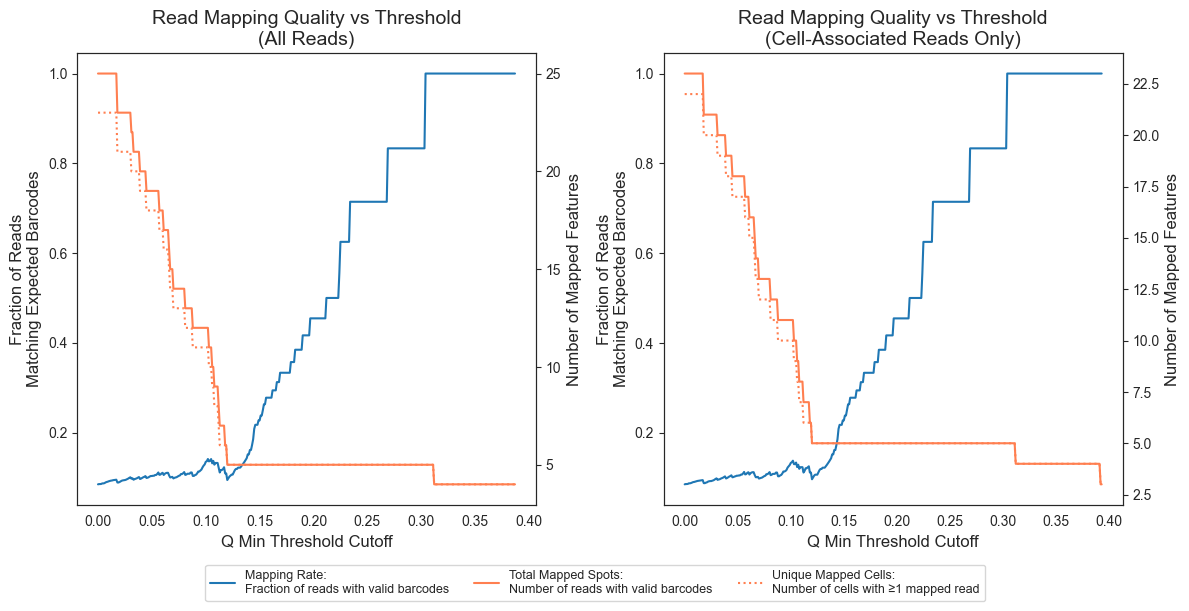

In [ ]:
print("Mapping rate vs. Q_min for determining optimal sequence quality cutoff:")
plot_mapping_vs_threshold(df_reads, barcodes, "Q_min")
plt.show()

#### Left Plot (All Reads):
- Shows how Q_min threshold affects all detected reads
- Blue line: Mapping rate (fraction of reads matching expected barcodes)
- Solid red line: Total number of mapped spots (reads with valid barcodes)
- Dotted red line: Number of unique cells with at least one mapped read

#### Right Plot (Cell-Associated Reads Only):
- Shows the same metrics but only for reads associated with cells

#### Interpreting Q_min Results:
With our optimized peak threshold, these plots confirm that adjusting Q_min provides little benefit:
- The mapping rate (blue line) is already very high at Q_min = 0
- Increasing Q_min only marginally improves mapping rate 
- However, this comes at a significant cost:
  - Total mapped spots and mapped cells decreases substantially
- The small gain in mapping rate doesn't justify the large loss of data

In [ ]:
# Automatically set parameters for preparing reads dataframe
MAP_START, MAP_END, RECOMB_START, RECOMB_END = compute_barcode_cycle_positions(
    MAP_PREFIX_LENGTH,
    RECOMB_PREFIX_LENGTH,
    SEQUENCING_ORDER,
    SKIP_CYCLES_MAP,
    SKIP_CYCLES_RECOMB,
)

print("Positions of nucleotides for mapping and recombination calculations:")
print(f"MAP_START = {MAP_START}")
print(f"MAP_END = {MAP_END}")
print(f"RECOMB_START = {RECOMB_START}")
print(f"RECOMB_END = {RECOMB_END}")

# Define columns for mapping and recombination
MAP_COL = 'prefix_map'
RECOMB_COL = 'prefix_recomb'
RECOMB_FILTER_COL = 'Q_recomb'


Positions of nucleotides for mapping and recombination calculations:
MAP_START = 1
MAP_END = 7
RECOMB_START = 8
RECOMB_END = 9


In [ ]:
# Define parameters for read mapping
Q_MIN = 0
ERROR_CORRECT = True
RECOMB_Q_THRESHOLD = 0.5
BARCODE_INFO_COLS = ['gene_symbol']
# Define further error correction parameters if wanted (e.g. MAX_DISTANCE, DISTANCE_METRIC)
MAX_DISTANCE = 2
SORT_CALLS = "peak"

In [ ]:
display(df_barcode_library)

,prefix_map,gene_symbol,uniprot_entry,prefix_recomb
0,CACCTTA,ATF4,NaN,AA
1,CTTTAGG,ATF4,NaN,AG
2,TGGGTTC,CDKN1A,NaN,AT
3,TCTAGCC,CDKN1A,NaN,GT
4,CACAGAA,COG2,NaN,AC
...,...,...,...,...
88,CAGAAAG,USP7,NaN,AG
89,TCTCGGA,VPS4A,NaN,AC
90,CGAATCG,VPS4A,NaN,AT
91,CTTACGA,ZBP1,NaN,AA


Preparing reads
Available quality columns: ['Q_0', 'Q_1', 'Q_2', 'Q_3', 'Q_4', 'Q_5', 'Q_6', 'Q_7', 'Q_8']
Maximum cycle available: 9
Requested mapping range: cycles 1-7
Requested recombination range: cycles 8-9
Corrected cells:
performing error correction
[Debug] Peak Width: 5, Threshold: 175
[Debug] Mapped cells: 212


,cell,tile,well,prefix_recomb,cell_barcode_0,pre_correction_cell_barcode_0,no_recomb_0,peak_0,cell_barcode_1,no_recomb_1,peak_1,gene_symbol_0,gene_symbol_1
0,3,123,A3,TG,TGAAAGC,TGAAAAC,NaN,211.140225,TGAAAGC,NaN,186.963613,RIPK3,RIPK3
1,4,123,A3,GC,TGAAAGC,TGAAAAC,NaN,1428.859636,NaN,NaN,NaN,RIPK3,NaN
2,5,123,A3,AC,CTAGAAC,ATAGAAC,NaN,471.150209,TGCAACT,NaN,460.284743,PDCD6IP,STAT3


Minimal phenotype features:


,area,i,j,cell,bounds,tile,well
0,142.0,6.028169,304.197183,1,"(0, 296, 12, 313)",123,A3
1,77.0,6.025974,87.883117,2,"(0, 83, 12, 93)",123,A3
2,196.0,9.602041,165.846939,3,"(0, 159, 22, 173)",123,A3
3,149.0,7.409396,137.261745,4,"(0, 130, 15, 144)",123,A3
4,168.0,14.083333,290.535714,5,"(8, 282, 24, 300)",123,A3
...,...,...,...,...,...,...,...
349,130.0,1188.984615,557.792308,350,"(1181, 551, 1196, 566)",123,A3
350,97.0,1194.134021,181.505155,351,"(1189, 177, 1200, 189)",123,A3
351,74.0,1196.391892,216.432432,352,"(1191, 210, 1200, 226)",123,A3
352,109.0,1195.724771,232.495413,353,"(1190, 220, 1200, 243)",123,A3


Summary of the fraction of cells mapping to one barcode:


,well,tile,fraction of cells mapping to 1 gene symbols
1,A3,123,0.418079


Summary of the fraction of cells mapping to any barcode:


,well,tile,fraction of cells mapping to >=1 gene symbols
1,A3,123,0.5


Histogram of the number of reads per cell:


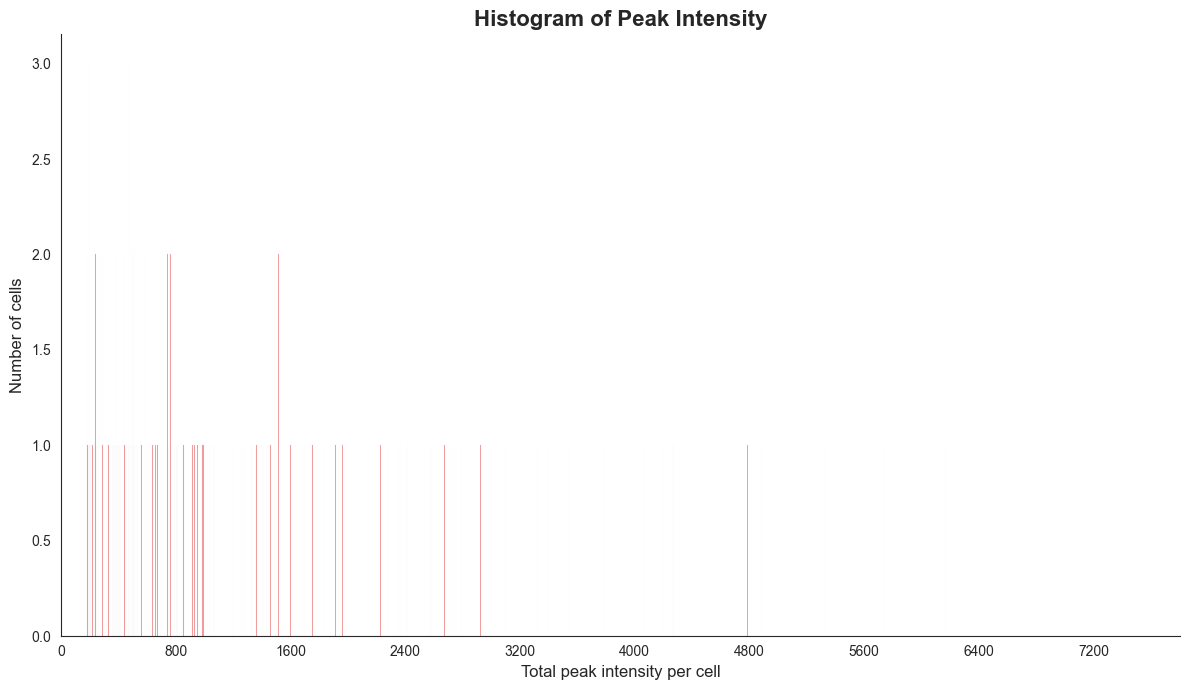

Histogram of the number of counts of each unique gene symbols:


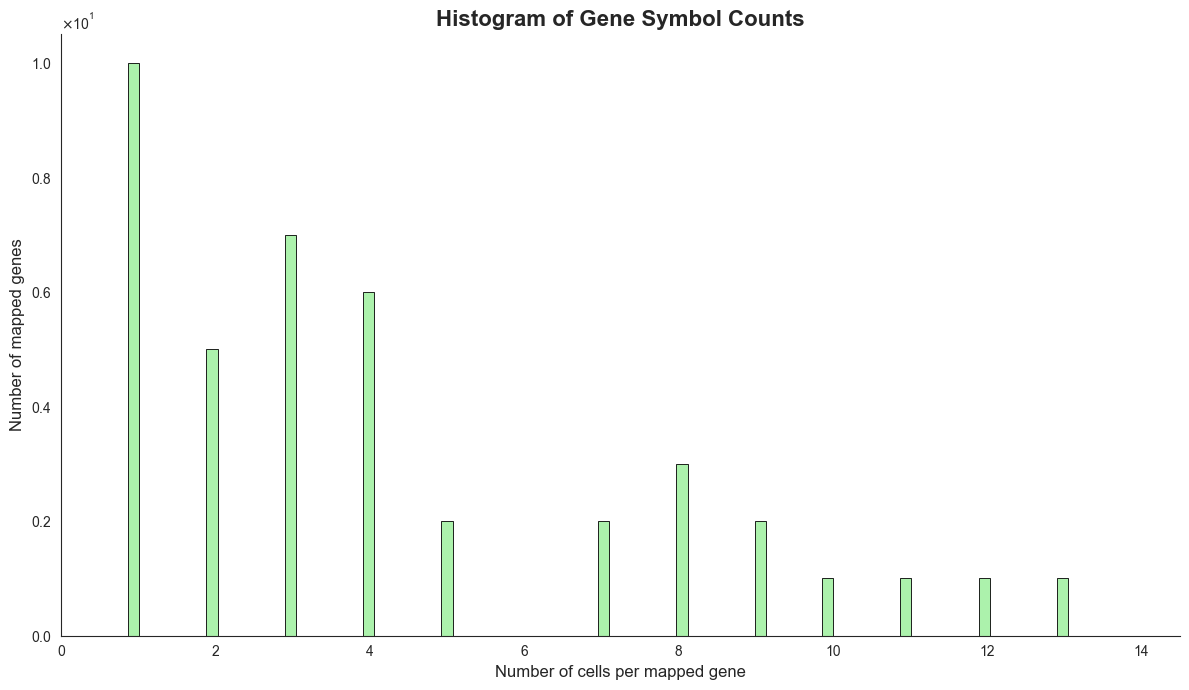

In [87]:
print("Preparing reads")
df_reads_multi = prep_multi_reads(
    df_reads,
    map_start=MAP_START,
    map_end=MAP_END,
    recomb_start=RECOMB_START,
    recomb_end=RECOMB_END,
    map_col=MAP_COL,
    recomb_col=RECOMB_COL
)

print("Corrected cells:")
df_cells = call_cells_multi(
    df_reads_multi,
    df_barcode_library=df_barcode_library,
    q_min=Q_MIN,
    error_correct=ERROR_CORRECT,
    map_col=MAP_COL,
    recomb_col=RECOMB_COL,
    recomb_filter_col=RECOMB_FILTER_COL,
    recomb_q_thresh=RECOMB_Q_THRESHOLD,
)

# Debug print
peak_width = PEAK_WIDTH
threshold_reads = THRESHOLD_READS
print(f"[Debug] Peak Width: {peak_width}, Threshold: {threshold_reads}")
print(f"[Debug] Mapped cells: {len(df_cells)}")
display(df_cells.head(3))

print("Minimal phenotype features:")
df_sbs_info = extract_phenotype_minimal(
    phenotype_data=nuclei, nuclei_data=nuclei, wildcards=WILDCARDS
)
display(df_sbs_info)

print("Summary of the fraction of cells mapping to one barcode:")
one_barcode_mapping = plot_cell_mapping_heatmap(
    df_cells,
    df_sbs_info,
    barcodes,
    mapping_to="one",
    mapping_strategy="gene symbols",
    shape="6W_sbs",
    return_plot=False,
    return_summary=True,
)
display(one_barcode_mapping)

print("Summary of the fraction of cells mapping to any barcode:")
any_barcode_mapping = plot_cell_mapping_heatmap(
    df_cells,
    df_sbs_info,
    barcodes,
    mapping_to="any",
    mapping_strategy="gene symbols",
    shape="6W_sbs",
    return_plot=False,
    return_summary=True,
)
display(any_barcode_mapping)

print("Histogram of the number of reads per cell:")
outliers = plot_cell_metric_histogram(df_cells, sort_by=SORT_CALLS)
plt.show()

print("Histogram of the number of counts of each unique gene symbols:")
outliers = plot_gene_symbol_histogram(df_cells)
plt.show()

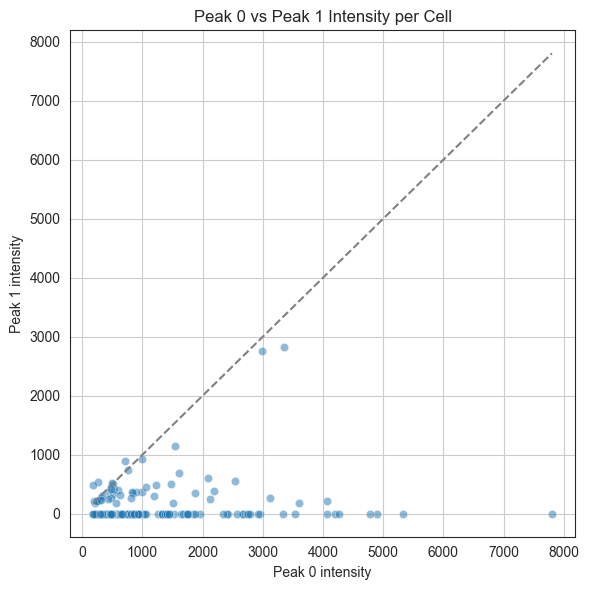

20.75% of cells have peak_1 >= 10% of peak_0 (44 out of 212)


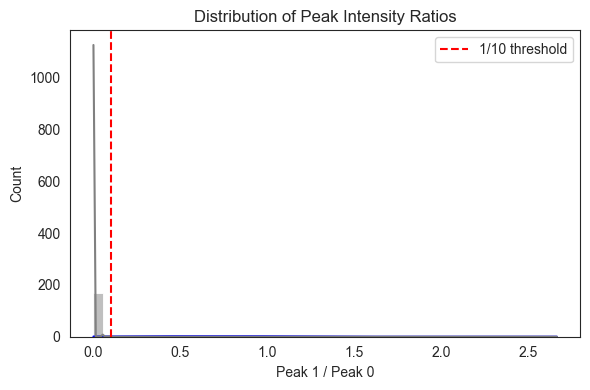

In [88]:
# Clean and prepare data
df_clean = df_cells.copy()

# Keep only rows with positive, non-missing peak_0
df_clean = df_clean[df_clean['peak_0'].notna() & (df_clean['peak_0'] > 0)]

# Replace NaN in peak_1 with 0
df_clean['peak_1'] = df_clean['peak_1'].fillna(0)

# Calculate ratio and flag significant peak_1
df_clean['peak_ratio'] = df_clean['peak_1'] / df_clean['peak_0']
df_clean['significant_peak_1'] = df_clean['peak_ratio'] >= 0.1

# Plot peak_0 vs peak_1 scatter
plt.figure(figsize=(6, 6))
sns.scatterplot(data=df_clean, x='peak_0', y='peak_1', alpha=0.5)
plt.plot([df_clean['peak_0'].min(), df_clean['peak_0'].max()],
         [df_clean['peak_0'].min(), df_clean['peak_0'].max()],
         linestyle='--', color='gray')
plt.xlabel('Peak 0 intensity')
plt.ylabel('Peak 1 intensity')
plt.title('Peak 0 vs Peak 1 Intensity per Cell')
plt.grid(True)
plt.tight_layout()
plt.show()

# Print percent of cells with significant peak_1
num_significant = df_clean['significant_peak_1'].sum()
total = len(df_clean)
percent = (num_significant / total) * 100 if total > 0 else 0
print(f"{percent:.2f}% of cells have peak_1 >= 10% of peak_0 "
      f"({num_significant} out of {total})")

# Plot histogram of peak ratios
plt.figure(figsize=(6, 4))
sns.histplot(data=df_clean, x='peak_ratio', bins=50,
             hue='significant_peak_1', kde=True, palette=['gray', 'blue'])
plt.axvline(0.1, color='red', linestyle='--', label='1/10 threshold')
plt.xlabel('Peak 1 / Peak 0')
plt.title('Distribution of Peak Intensity Ratios')
plt.legend()
plt.tight_layout()
plt.show()


## Parameter Optimization

Testing 64 parameter combinations...
Available quality columns: ['Q_0', 'Q_1', 'Q_2', 'Q_3', 'Q_4', 'Q_5', 'Q_6', 'Q_7', 'Q_8']
Maximum cycle available: 9
Requested mapping range: cycles 1-7
Requested recombination range: cycles 8-9
performing error correction
Available quality columns: ['Q_0', 'Q_1', 'Q_2', 'Q_3', 'Q_4', 'Q_5', 'Q_6', 'Q_7', 'Q_8']
Maximum cycle available: 9
Requested mapping range: cycles 1-7
Requested recombination range: cycles 8-9
performing error correction
Available quality columns: ['Q_0', 'Q_1', 'Q_2', 'Q_3', 'Q_4', 'Q_5', 'Q_6', 'Q_7', 'Q_8']
Maximum cycle available: 9
Requested mapping range: cycles 1-7
Requested recombination range: cycles 8-9
performing error correction
Available quality columns: ['Q_0', 'Q_1', 'Q_2', 'Q_3', 'Q_4', 'Q_5', 'Q_6', 'Q_7', 'Q_8']
Maximum cycle available: 9
Requested mapping range: cycles 1-7
Requested recombination range: cycles 8-9
performing error correction
Available quality columns: ['Q_0', 'Q_1', 'Q_2', 'Q_3', 'Q_4', 'Q_5

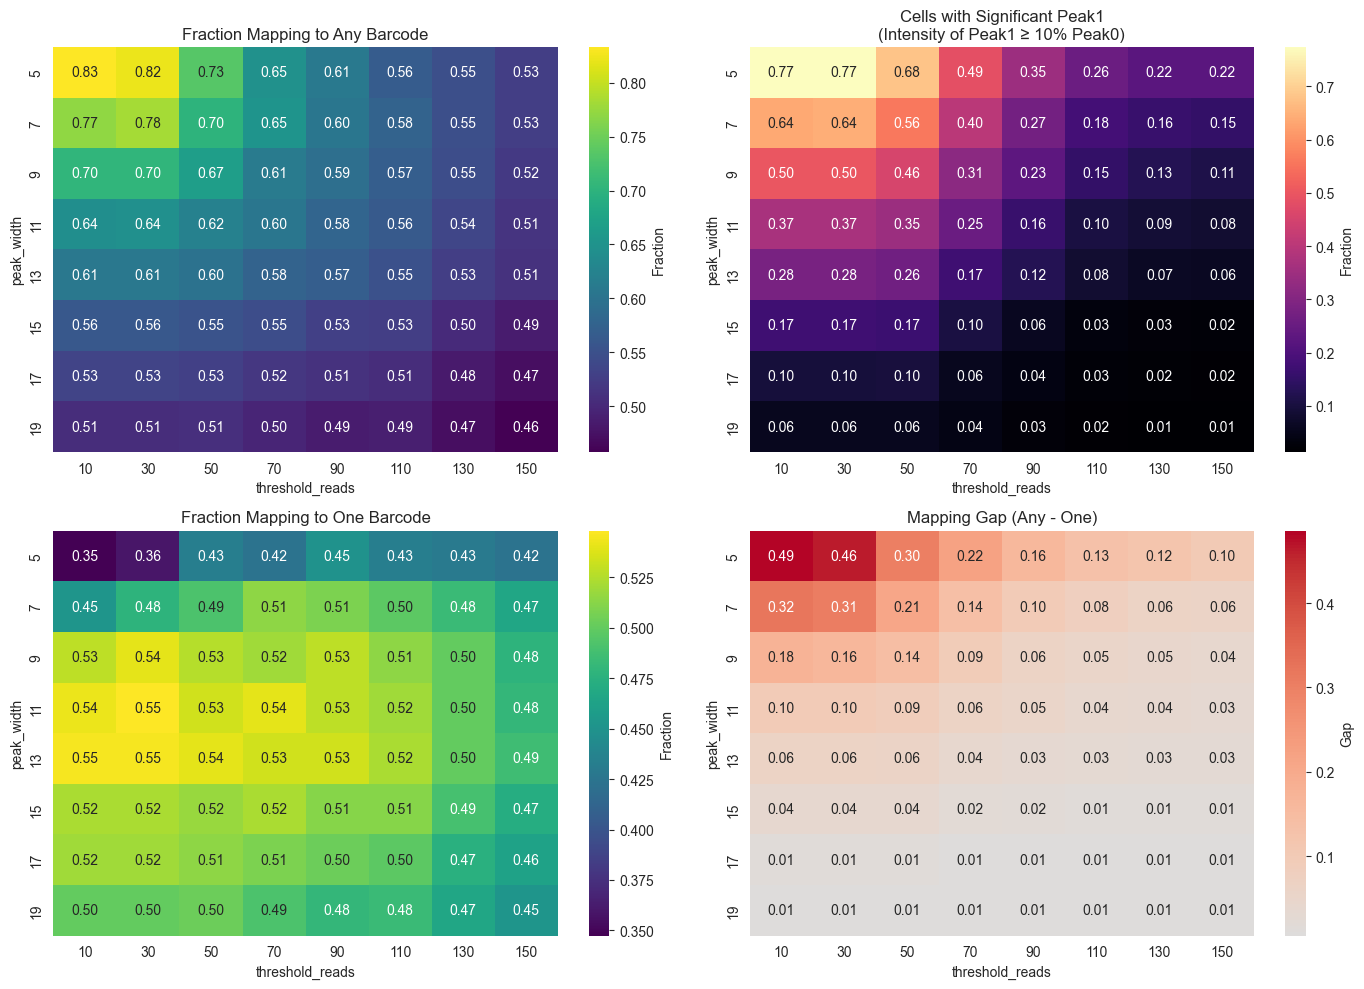

,peak_width,threshold_reads,total_reads,fraction_one_barcode,fraction_any_barcode,cells_with_one_barcode,cells_with_any_barcode,total_cells,status,fraction_peak1_significant,n_cells,mapping_gap
0,5,10,54033,0.347458,0.833333,123,295,354,success,0.774011,354,0.485876
1,5,30,23029,0.358757,0.822034,127,291,354,success,0.772080,351,0.463277
2,5,50,1957,0.432203,0.734463,153,260,354,success,0.681818,330,0.302260
3,5,70,1013,0.423729,0.646893,150,229,354,success,0.485246,305,0.223164
4,5,90,557,0.449153,0.610169,159,216,354,success,0.346429,280,0.161017
...,...,...,...,...,...,...,...,...,...,...,...,...
59,19,70,398,0.491525,0.497175,174,176,354,success,0.042471,259,0.005650
60,19,90,304,0.480226,0.485876,170,172,354,success,0.028455,246,0.005650
61,19,110,267,0.483051,0.488701,171,173,354,success,0.017391,230,0.005650
62,19,130,250,0.466102,0.471751,165,167,354,success,0.013699,219,0.005650


In [89]:
# Define parameter ranges to test
PEAK_WIDTH_RANGE = [5, 7, 9, 11, 13, 15, 17, 19] 
THRESHOLD_RANGE = [10, 30, 50, 70, 90, 110, 130, 150]  

print(f"Testing {len(PEAK_WIDTH_RANGE) * len(THRESHOLD_RANGE)} parameter combinations...")

# Run parameter search (replace with your actual variables)
results_df, df_cells = automated_parameter_search(
    aligned_images=aligned,
    nuclei_mask=nuclei,
    barcodes=barcodes,
    df_barcode_library=df_barcode_library,
    wildcards=WILDCARDS,
    bases=BASES,
    extra_channel_indices=EXTRA_CHANNEL_INDICES,
    max_filter_width=MAX_FILTER_WIDTH,
    peak_width_range=PEAK_WIDTH_RANGE,
    threshold_range=THRESHOLD_RANGE,    
    call_reads_method=CALL_READS_METHOD,
    map_start=MAP_START,
    map_end=MAP_END,
    recomb_start=RECOMB_START,
    recomb_end=RECOMB_END,
    map_col=MAP_COL,
    recomb_col=RECOMB_COL,
    recomb_filter_col=RECOMB_FILTER_COL,
    q_min=Q_MIN,
    error_correct=True,
    recomb_q_thresh=RECOMB_Q_THRESHOLD,
    sort_calls=SORT_CALLS,
    verbose=False,
)

# Visualize results (pass df_cells if you want peak fraction analysis)
visualize_parameter_results(results_df, df_cells=df_cells, save_plots=False)

### Calculate best parameters
- `"accuracy"`: lowest `fraction_peak1_significant` with highest `fraction_any_barcode`
- `"single_peak"`: highest `'fraction_one_barcode'`
- `"balanced"`: highest `fraction_any_barcode` with `fraction_peak1_significant` <= 0.5

In [90]:
# Get recommendations
get_best_parameters(results_df, df_cells, priority="balanced")


Best parameters for balanced (high any-barcode with low peak1 significance):
  PEAK_WIDTH = 15
  THRESHOLD_READS = 110
  One-barcode mapping: 0.511
  Any-barcode mapping: 0.525
  Peak1 significance: 0.033
  Total reads: 295


peak_width                          15
threshold_reads                    110
total_reads                        295
fraction_one_barcode          0.511299
fraction_any_barcode          0.525424
cells_with_one_barcode             181
cells_with_any_barcode             186
total_cells                        354
status                         success
fraction_peak1_significant     0.03252
n_cells                            246
Name: 45, dtype: object

## Add sbs process parameters to config file

The `mode` parameter in the config file determines how Snakemake will execute parameter searches for segmentation optimization. Setting the `mode` to `segment_sbs_paramsearch` will systematically explore combinations of parameters for segmentation accuracy. This is not yet implemented.

In [91]:
# # Add sbs section
# config["sbs"] = {
#     "alignment_method": ALIGNMENT_METHOD,
#     "channel_names": CHANNEL_NAMES,
#     "upsample_factor": UPSAMPLE_FACTOR,
#     "skip_cycles_indices": SKIP_CYCLES_INDICES,
#     "manual_background_cycle_index": MANUAL_BACKGROUND_CYCLE_INDEX,
#     "extra_channel_indices": EXTRA_CHANNEL_INDICES,
#     "max_filter_width": MAX_FILTER_WIDTH,
#     "spot_detection_method": SPOT_DETECTION_METHOD,
#     "dapi_cycle": DAPI_CYCLE,
#     "cyto_cycle": CYTO_CYCLE,
#     "cyto_cycle_index": CYTO_CYCLE_INDEX,
#     "dapi_index": DAPI_INDEX,
#     "cyto_index": CYTO_INDEX,
#     "segmentation_method": SEGMENTATION_METHOD,
#     "gpu": GPU,
#     "segment_cells": SEGMENT_CELLS,
#     "df_barcode_library_fp": DF_BARCODE_LIBRARY_FP,
#     "sequencing_order": SEQUENCING_ORDER,
#     "threshold_peaks": THRESHOLD_READS,
#     "call_reads_method": CALL_READS_METHOD,
#     "bases": BASES,
#     "q_min": Q_MIN,
#     "recomb_start": RECOMB_START,
#     "recomb_end": RECOMB_END,
#     "map_start": MAP_START,
#     "map_end": MAP_END,
#     "map_col": MAP_COL,
#     "recomb_col": RECOMB_COL,
#     "recomb_filter_col": RECOMB_FILTER_COL,
#     "error_correct": ERROR_CORRECT,
#     "recomb_q_thresh": RECOMB_Q_THRESHOLD,
#     "barcode_info_cols": BARCODE_INFO_COLS,
#     "max_distance": MAX_DISTANCE,
#     "sort_calls": SORT_CALLS,
#     "mode": None,
# }

# # Add spot detection method specific parameters
# if SPOT_DETECTION_METHOD == "standard":
#     config["sbs"].update({
#         "peak_width": PEAK_WIDTH,
#     })
# elif SPOT_DETECTION_METHOD == "spotiflow":
#     config["sbs"].update({
#         "spotiflow_cycle_index": SPOTIFLOW_CYCLE_INDEX,
#         "spotiflow_model": SPOTIFLOW_MODEL,
#         "spotiflow_threshold": SPOTIFLOW_THRESHOLD,
#         "spotiflow_min_distance": SPOTIFLOW_MIN_DISTANCE,
#     })

# # Add method-specific parameters based on segmentation method
# if SEGMENTATION_METHOD == "cellpose":
#     config["sbs"].update({
#         "nuclei_diameter": NUCLEI_DIAMETER,
#         "cell_diameter": CELL_DIAMETER,
#         "nuclei_flow_threshold": NUCLEI_FLOW_THRESHOLD,
#         "nuclei_cellprob_threshold": NUCLEI_CELLPROB_THRESHOLD,
#         "cell_flow_threshold": CELL_FLOW_THRESHOLD,
#         "cell_cellprob_threshold": CELL_CELLPROB_THRESHOLD,
#         "cyto_model": CELLPOSE_MODEL,
#     })
# elif SEGMENTATION_METHOD == "microsam":
#     config["sbs"].update({
#         "microsam_model": MICROSAM_MODEL,
#     })
# elif SEGMENTATION_METHOD == "stardist":
#     config["sbs"].update({
#         "stardist_model": STARDIST_MODEL,
#         "nuclei_prob_threshold": NUCLEI_PROB_THRESHOLD,
#         "nuclei_nms_threshold": NUCLEI_NMS_THRESHOLD,
#         "cell_prob_threshold": CELL_PROB_THRESHOLD,
#         "cell_nms_threshold": CELL_NMS_THRESHOLD,
#     })
# elif SEGMENTATION_METHOD == "watershed":
#     config["sbs"].update({
#         "threshold_dapi": THRESHOLD_DAPI,
#         "nucleus_area_min": NUCLEUS_AREA[0],
#         "nucleus_area_max": NUCLEUS_AREA[1],
#         "threshold_cell": THRESHOLD_CELL,
#         "log_transform": LOG_TRANSFORM,
#     })

# # Write the updated configuration back with markdown-style comments
# with open(CONFIG_FILE_PATH, "w") as config_file:
#     # Write the introductory markdown-style comments
#     config_file.write(CONFIG_FILE_HEADER)

#     # Dump the updated YAML structure, keeping markdown comments for sections
#     yaml.dump(config, config_file, default_flow_style=False, sort_keys=False)


# # New resize parameters
#   resize_cycles: true  # Enable automatic resizing of mismatched spatial dimensions
#   target_spatial_shape: null  # Auto-determine target shape (or specify [height, width])
#   resize_method: "downsample_majority"  # Options: "downsample_majority", "upsample_majority", "smallest", "largest"
